# Sustainability Project Notebook

## Import Libraries and Read CSV Files

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import cvxpy as cp
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

In [45]:
# each is_yyyy dataframe contains data for the monthly returns of the last 10 years. 
# is_2013 is the investment set used for building the 2014 portfolio as it contains returns from Jan. 2004 to Dec. 2013.

for year in range(2013, 2026):
    exec(f'is_{year} = pd.read_csv(f"processed_data/data_investment_set/investment_set_{year}.csv")')
    print(f'is_{year} loaded successfully.')



is_2013 loaded successfully.
is_2014 loaded successfully.
is_2015 loaded successfully.
is_2016 loaded successfully.
is_2017 loaded successfully.
is_2018 loaded successfully.
is_2019 loaded successfully.
is_2020 loaded successfully.
is_2021 loaded successfully.
is_2022 loaded successfully.
is_2023 loaded successfully.
is_2024 loaded successfully.
is_2025 loaded successfully.


## Value-Weighted Portfolio

### Computation of the Weights

In [46]:
# Calculation of the weights for each investment set
for year in range(2013, 2026):
    df = globals()[f'is_{year}']

    # Creation of the new column 'MV_Y_weight'
    df['MV_Y_weight'] = df['MV_Y'] / df['MV_Y'].sum()

    # Relocation of 'MV_Y_weight' to the sixth position
    cols = list(df.columns)
    cols.remove('MV_Y_weight')
    cols.insert(5, 'MV_Y_weight')
    globals()[f'is_{year}'] = df[cols]

    # Sum of weights to verify that it equals 1
    print(f"Sum of weights for {year}: {df['MV_Y_weight'].sum()}")

# (Display of is_2013 to verify the new column and its position)
is_2013

Sum of weights for 2013: 0.9999999999999999
Sum of weights for 2014: 1.0
Sum of weights for 2015: 1.0
Sum of weights for 2016: 1.0
Sum of weights for 2017: 1.0
Sum of weights for 2018: 1.0
Sum of weights for 2019: 1.0
Sum of weights for 2020: 0.9999999999999999
Sum of weights for 2021: 1.0
Sum of weights for 2022: 1.0
Sum of weights for 2023: 1.0
Sum of weights for 2024: 1.0000000000000002
Sum of weights for 2025: 1.0


/var/folders/b3/wvshm2ws24dc4b18w65382sh0000gn/T/ipykernel_70404/210435052.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['MV_Y_weight'] = df['MV_Y'] / df['MV_Y'].sum()


,ISIN,NAME,Country,Region,MV_Y,MV_Y_weight,CO2_S1,CO2_S2,REV,CI,...,2013-03-29 00:00:00,2013-04-30 00:00:00,2013-05-31 00:00:00,2013-06-28 00:00:00,2013-07-31 00:00:00,2013-08-30 00:00:00,2013-09-30 00:00:00,2013-10-31 00:00:00,2013-11-29 00:00:00,2013-12-31 00:00:00
0,AN8068571086,SLB,US,AMER,105861.90,0.005598,1790000.0,430000.0,42149000.0,52.6703,...,-0.0380,-0.0061,-0.0188,-0.0146,0.1349,-0.0010,0.0917,0.0607,-0.0566,0.0227
1,AT000000STR1,STRABAG SE,AT,EUR,3087.59,0.000163,968759.0,295141.0,17782013.0,71.0774,...,-0.0889,0.0266,-0.0669,-0.0270,0.0828,-0.0430,0.1655,0.0549,0.1161,-0.0004
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR,8185.61,0.000433,5161.0,43060.0,13350128.0,3.6120,...,-0.1008,0.0375,-0.0315,-0.1490,0.1007,0.1284,-0.0434,0.1239,0.0031,-0.0436
3,AT0000652011,ERSTE GROUP BANK,AT,EUR,13245.36,0.000700,32753.0,84281.0,16802146.0,6.9654,...,-0.1350,0.1245,0.0511,-0.1794,0.1433,0.0550,-0.0113,0.1167,-0.0010,-0.0106
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR,3381.96,0.000179,27476.0,195246.0,5930020.0,37.5584,...,-0.0064,0.0442,-0.0014,-0.0686,0.0974,0.0339,0.1697,-0.0169,0.0330,-0.1099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,US98389B1008,XCEL ENERGY,US,AMER,13656.38,0.000722,56535330.0,774475.0,10128223.0,5658.4265,...,0.0446,0.0704,-0.0966,-0.0038,0.0568,-0.0678,-0.0009,0.0453,-0.0291,0.0071
799,US9839191015,XILINX DEAD - DELIST.15/02/22,US,AMER,9719.62,0.000514,1685.0,26545.0,2195457.0,12.8584,...,0.0241,-0.0068,0.0794,-0.0256,0.1787,-0.0650,0.0790,-0.0304,-0.0166,0.0335
800,US98421M1062,XEROX HOLDINGS,US,AMER,9815.17,0.000519,127000.0,186000.0,22390000.0,13.9795,...,0.0675,-0.0023,0.0245,0.0385,0.0695,0.0289,0.0367,-0.0340,0.1449,0.0744
801,US9884981013,YUM! BRANDS,US,AMER,29787.74,0.001575,156510.0,2377372.0,13633000.0,185.8639,...,0.0987,-0.0483,-0.0054,0.0235,0.0565,-0.0398,0.0196,-0.0475,0.1488,-0.0267


###  Calculating the Results of the 2014 Portfolio 

In [47]:
# Creation of new DataFrame with the weights and ISINs from is_2013
value_weighted_portfolio_2014 = is_2013[["ISIN", "NAME", "MV_Y_weight"]].copy()

# Selection of the 2014 returns columns (the last 12) and include 'ISIN' and 'Name'
columns_to_select = ['ISIN'] + list(is_2014.columns[-12:])
returns_2014 = is_2014[columns_to_select]

# Merging the 2014 returns with its Value Weighted Portfolio DataFrame on the 'ISIN' column
value_weighted_portfolio_2014 = value_weighted_portfolio_2014.merge(returns_2014, on='ISIN', how='left')

# 2014 Value Weighted Portfolio with returns
value_weighted_portfolio_2014


,ISIN,NAME,MV_Y_weight,2014-01-31 00:00:00,2014-02-28 00:00:00,2014-03-31 00:00:00,2014-04-30 00:00:00,2014-05-30 00:00:00,2014-06-30 00:00:00,2014-07-31 00:00:00,2014-08-29 00:00:00,2014-09-30 00:00:00,2014-10-31 00:00:00,2014-11-28 00:00:00,2014-12-31 00:00:00
0,AN8068571086,SLB,0.005598,-0.0282,0.0667,0.0484,0.0415,0.0245,0.1381,-0.0811,0.0152,-0.0725,-0.0298,-0.1288,-0.0016
1,AT000000STR1,STRABAG SE,0.000163,0.0145,-0.0852,-0.0497,0.0782,0.0596,0.0626,-0.1331,0.0264,-0.1411,-0.0818,0.0652,-0.0462
2,AT0000606306,RAIFFEISEN BANK INTL.,0.000433,0.1367,-0.0926,-0.0436,-0.0542,0.0628,-0.0090,-0.1369,-0.0677,-0.1531,-0.0197,-0.0272,-0.2688
3,AT0000652011,ERSTE GROUP BANK,0.000700,0.0433,-0.0249,-0.0374,-0.0187,0.0455,-0.0703,-0.2033,-0.0015,-0.1095,0.1108,0.0670,-0.1428
4,AT0000720008,TELEKOM AUSTRIA,0.000179,0.1535,0.1139,0.0206,-0.0032,-0.0182,0.0114,-0.0213,-0.0197,-0.0390,-0.1687,-0.0086,-0.0233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,US98389B1008,XCEL ENERGY,0.000722,0.0347,0.0477,0.0122,0.0497,-0.0348,0.0581,-0.0444,0.0406,-0.0424,0.1010,0.0140,0.0673
799,US9839191015,XILINX DEAD - DELIST.15/02/22,0.000514,0.0109,0.1307,0.0397,-0.1305,0.0012,0.0075,-0.1306,0.0344,0.0024,0.0503,0.0283,-0.0473
800,US98421M1062,XEROX HOLDINGS,0.000519,-0.1085,0.0129,0.0341,0.0699,0.0215,0.0124,0.0659,0.0415,-0.0374,0.0038,0.0512,-0.0027
801,US9884981013,YUM! BRANDS,0.001575,-0.1074,0.1032,0.0177,0.0261,0.0042,0.0503,-0.1415,0.0437,-0.0062,0.0040,0.0755,-0.0570


In [48]:
# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio return for each month
value_weighted_portfolio_2014_returns = value_weighted_portfolio_2014.iloc[:, 3:].mul(value_weighted_portfolio_2014['MV_Y_weight'], axis=0).sum()
value_weighted_portfolio_2014_returns

2014-01-31 00:00:00   -0.036073
2014-02-28 00:00:00    0.054132
2014-03-31 00:00:00    0.007866
2014-04-30 00:00:00    0.018191
2014-05-30 00:00:00    0.015617
2014-06-30 00:00:00    0.011431
2014-07-31 00:00:00   -0.022088
2014-08-29 00:00:00    0.022326
2014-09-30 00:00:00   -0.025609
2014-10-31 00:00:00    0.000225
2014-11-28 00:00:00    0.024581
2014-12-31 00:00:00   -0.019277
dtype: float64

### Calculating the Results of Every Year by Creating a Function Based on the Above Code

In [49]:
def calculate_value_weighted_portfolio_returns(start_year, end_year):
    value_weighted_returns = {}

    for year in range(start_year, end_year + 1):
        try:
            prev_year = year - 1
            prev_df = globals()[f'is_{prev_year}']  # Get investment set DataFrame
            current_df = globals()[f'is_{year}']   # Get current year returns

            value_weighted_portfolio_yyyy = prev_df.loc[:, ("ISIN", "NAME", "MV_Y_weight")].copy()
            columns_to_select = ['ISIN'] + list(current_df.columns[-12:])
            returns_yyyy = current_df[columns_to_select]

            value_weighted_portfolio_yyyy = value_weighted_portfolio_yyyy.merge(returns_yyyy, on='ISIN', how='left')
            value_weighted_portfolio_yyyy_returns = value_weighted_portfolio_yyyy.iloc[:, 3:].mul(value_weighted_portfolio_yyyy['MV_Y_weight'], axis=0).sum()

            value_weighted_returns[year] = value_weighted_portfolio_yyyy_returns

        except Exception as e:
            print(f"Error processing year {year}: {e}")

    return value_weighted_returns

value_weighted_returns = calculate_value_weighted_portfolio_returns(2014, 2025)

In [50]:
# Creation of a DataFrame from the value_weighted_returns dictionary
def create_returns_dataframe(value_weighted_returns_dict):
    # Initialize empty DataFrame with years as index and months as columns
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df = pd.DataFrame(index=sorted(value_weighted_returns_dict.keys()), columns=months)

    # Populate the DataFrame
    for year, returns in value_weighted_returns_dict.items():
        df.loc[year] = returns.values

    return df

# Get the number of assets for each year
for year in range(2013, 2026):
    num_assets = len(globals()[f'is_{year}'])
    print(f"Number of assets with at least 4 years of data for {year}: {num_assets}")

value_weighted_portfolio_returns_df = create_returns_dataframe(value_weighted_returns)
value_weighted_portfolio_returns_df

Number of assets with at least 4 years of data for 2013: 803
Number of assets with at least 4 years of data for 2014: 834
Number of assets with at least 4 years of data for 2015: 869
Number of assets with at least 4 years of data for 2016: 889
Number of assets with at least 4 years of data for 2017: 924
Number of assets with at least 4 years of data for 2018: 980
Number of assets with at least 4 years of data for 2019: 1074
Number of assets with at least 4 years of data for 2020: 1121
Number of assets with at least 4 years of data for 2021: 1159
Number of assets with at least 4 years of data for 2022: 1160
Number of assets with at least 4 years of data for 2023: 1146
Number of assets with at least 4 years of data for 2024: 1128
Number of assets with at least 4 years of data for 2025: 1111


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.036073,0.054132,0.007866,0.018191,0.015617,0.011431,-0.022088,0.022326,-0.025609,0.000225,0.024581,-0.019277
2015,-0.023956,0.060384,-0.020122,0.028179,0.000398,-0.024719,0.018982,-0.063968,-0.035347,0.078765,-0.008175,-0.027718
2016,-0.055225,-0.00378,0.073652,0.018299,0.005943,-0.017208,0.041557,0.005956,0.00254,-0.020009,0.019818,0.034682
2017,0.014644,0.030306,0.014557,0.019408,0.027144,0.002424,0.021292,-0.001141,0.028424,0.013895,0.024999,0.013984
2018,0.047312,-0.04897,-0.016743,0.012743,0.000035,0.00234,0.039607,0.00527,0.006229,-0.061881,0.013307,-0.080812
2019,0.080454,0.034346,0.011335,0.041109,-0.066263,0.073223,0.002844,-0.025744,0.031693,0.023969,0.031224,0.035967
2020,-0.014171,-0.090218,-0.145032,0.110129,0.037685,0.026677,0.03554,0.057468,-0.041721,-0.03273,0.162987,0.040866
2021,-0.012173,0.036578,0.050018,0.048155,0.022251,0.004683,0.015492,0.019158,-0.038854,0.055974,-0.026212,0.06123
2022,-0.03684,-0.025298,0.024008,-0.072222,0.005096,-0.086407,0.083894,-0.046596,-0.094245,0.08124,0.075282,-0.043181
2023,0.07844,-0.022239,0.033727,0.025486,-0.017188,0.06092,0.032352,-0.026291,-0.046666,-0.023822,0.093163,0.050721


### Value-Weighted Portfolio for firms with 10 Years of Available Data

In [51]:
# Drops rows (assets) with any NaN to get assets with full available data
is_2013_fa = is_2013.dropna(axis=0)  

# Creation of new DataFrame with the weights and ISINs from is_2013_fa
value_weighted_portfolio_2014_fa = is_2013_fa[["ISIN", "MV_Y_weight"]].copy()

# Renormalization of the weights to ensure they sum to 1 after dropping rows with NaN
value_weighted_portfolio_2014_fa['MV_Y_weight'] = value_weighted_portfolio_2014_fa['MV_Y_weight'] / value_weighted_portfolio_2014_fa['MV_Y_weight'].sum()

# Sum of weights to verify that it equals 1
print(f"Sum of weights for 2013 (full available data): {value_weighted_portfolio_2014_fa['MV_Y_weight'].sum()}")

# Selection of the 2014 returns columns (the last 12) and include 'ISIN'
columns_to_select_fa = ['ISIN'] + list(is_2014.columns[-12:])
returns_2014_fa = is_2014[columns_to_select_fa]

# Merging the 2014 returns with its Value Weighted Portfolio DataFrame on the 'ISIN' column
value_weighted_portfolio_2014_fa = value_weighted_portfolio_2014_fa.merge(returns_2014_fa, on='ISIN', how='left')

# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio return for each month
value_weighted_portfolio_2014_returns_fa = value_weighted_portfolio_2014_fa.iloc[:, 2:].mul(value_weighted_portfolio_2014_fa['MV_Y_weight'], axis=0).sum()
value_weighted_portfolio_2014_returns_fa

Sum of weights for 2013 (full available data): 1.0


2014-01-31 00:00:00   -0.037438
2014-02-28 00:00:00    0.054041
2014-03-31 00:00:00    0.009404
2014-04-30 00:00:00    0.018896
2014-05-30 00:00:00    0.015315
2014-06-30 00:00:00    0.011346
2014-07-31 00:00:00   -0.022260
2014-08-29 00:00:00    0.023186
2014-09-30 00:00:00   -0.025502
2014-10-31 00:00:00    0.000663
2014-11-28 00:00:00    0.025927
2014-12-31 00:00:00   -0.018979
dtype: float64

In [52]:
# Drops rows (assets) with any NaN to get assets with full available data
for year in range(2013, 2026):
    exec(f'is_{year}_fa = is_{year}.dropna(axis=0)')


# Function to calculate value-weighted portfolio returns for assets with full available data for each year
def calculate_value_weighted_portfolio_returns_fa(start_year, end_year):
    value_weighted_returns_fa = {}

    for year in range(start_year, end_year + 1):
        try:
            prev_year = year - 1
            prev_df_fa = globals()[f'is_{prev_year}_fa']  # Get investment set DataFrame with full available data
            current_df = globals()[f'is_{year}']   # Get current year returns

            value_weighted_portfolio_yyyy_fa = prev_df_fa.loc[:, ("ISIN", "MV_Y_weight")].copy()
            columns_to_select_fa = ['ISIN'] + list(current_df.columns[-12:])
            returns_yyyy_fa = current_df[columns_to_select_fa]

            value_weighted_portfolio_yyyy_fa = value_weighted_portfolio_yyyy_fa.merge(returns_yyyy_fa, on='ISIN', how='left')
            value_weighted_portfolio_yyyy_returns_fa = value_weighted_portfolio_yyyy_fa.iloc[:, 2:].mul(value_weighted_portfolio_yyyy_fa['MV_Y_weight'], axis=0).sum()

            value_weighted_returns_fa[year] = value_weighted_portfolio_yyyy_returns_fa

        except Exception as e:
            print(f"Error processing year {year}: {e}")

    return value_weighted_returns_fa

value_weighted_returns_fa = calculate_value_weighted_portfolio_returns_fa(2014, 2025)

# Get the number of assets with full available data for each year
for year in range(2013, 2026):
    num_assets_fa = len(globals()[f'is_{year}_fa'])
    print(f"Number of assets with full available data for {year}: {num_assets_fa}")

# Creation of a DataFrame from the value_weighted_returns_fa dictionary
value_weighted_portfolio_returns_fa_df = create_returns_dataframe(value_weighted_returns_fa)
value_weighted_portfolio_returns_fa_df

Number of assets with full available data for 2013: 751
Number of assets with full available data for 2014: 795
Number of assets with full available data for 2015: 846
Number of assets with full available data for 2016: 878
Number of assets with full available data for 2017: 914
Number of assets with full available data for 2018: 968
Number of assets with full available data for 2019: 1062
Number of assets with full available data for 2020: 1109
Number of assets with full available data for 2021: 1147
Number of assets with full available data for 2022: 1147
Number of assets with full available data for 2023: 1136
Number of assets with full available data for 2024: 1120
Number of assets with full available data for 2025: 1101


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.036007,0.051976,0.009045,0.018174,0.014729,0.010912,-0.021409,0.0223,-0.024528,0.000638,0.024936,-0.018253
2015,-0.022613,0.057917,-0.018867,0.02704,0.00068,-0.023739,0.018174,-0.062092,-0.033679,0.076171,-0.007272,-0.026923
2016,-0.054002,-0.003765,0.072489,0.018219,0.005902,-0.016044,0.040601,0.005793,0.002176,-0.020147,0.019453,0.034356
2017,0.014519,0.03017,0.014751,0.019372,0.027,0.0022,0.021233,-0.001204,0.028033,0.013702,0.024886,0.013984
2018,0.047052,-0.048745,-0.016621,0.012697,-0.000289,0.002523,0.039583,0.005483,0.006372,-0.061944,0.013289,-0.080395
2019,0.079612,0.034148,0.011463,0.040829,-0.06581,0.07256,0.002795,-0.025399,0.03159,0.024071,0.031206,0.035632
2020,-0.01392,-0.089702,-0.14358,0.109558,0.037261,0.026731,0.035577,0.056985,-0.041511,-0.032976,0.161787,0.040834
2021,-0.012222,0.036383,0.049722,0.048012,0.022079,0.004765,0.015526,0.019239,-0.03883,0.055881,-0.025928,0.061087
2022,-0.036633,-0.02526,0.024099,-0.071833,0.005103,-0.085979,0.08364,-0.046205,-0.093749,0.081057,0.074733,-0.042956
2023,0.077962,-0.02196,0.033839,0.025567,-0.016884,0.060556,0.031986,-0.026218,-0.046518,-0.023573,0.093144,0.050461


## Minimum-Variance Portfolio

### Computation of the Sample Covariance Matrix of 2004-2013 Returns

In [53]:
mv_is_2013 = is_2013.copy()
mv_is_2013 = mv_is_2013.set_index('ISIN')
mv_is_2013

,NAME,Country,Region,MV_Y,MV_Y_weight,CO2_S1,CO2_S2,REV,CI,2004-01-30 00:00:00,...,2013-03-29 00:00:00,2013-04-30 00:00:00,2013-05-31 00:00:00,2013-06-28 00:00:00,2013-07-31 00:00:00,2013-08-30 00:00:00,2013-09-30 00:00:00,2013-10-31 00:00:00,2013-11-29 00:00:00,2013-12-31 00:00:00
ISIN,,,,,,,,,,,,,,,,,,,,,
AN8068571086,SLB,US,AMER,105861.90,0.005598,1790000.0,430000.0,42149000.0,52.6703,0.1181,...,-0.0380,-0.0061,-0.0188,-0.0146,0.1349,-0.0010,0.0917,0.0607,-0.0566,0.0227
AT000000STR1,STRABAG SE,AT,EUR,3087.59,0.000163,968759.0,295141.0,17782013.0,71.0774,NaN,...,-0.0889,0.0266,-0.0669,-0.0270,0.0828,-0.0430,0.1655,0.0549,0.1161,-0.0004
AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR,8185.61,0.000433,5161.0,43060.0,13350128.0,3.6120,NaN,...,-0.1008,0.0375,-0.0315,-0.1490,0.1007,0.1284,-0.0434,0.1239,0.0031,-0.0436
AT0000652011,ERSTE GROUP BANK,AT,EUR,13245.36,0.000700,32753.0,84281.0,16802146.0,6.9654,0.0467,...,-0.1350,0.1245,0.0511,-0.1794,0.1433,0.0550,-0.0113,0.1167,-0.0010,-0.0106
AT0000720008,TELEKOM AUSTRIA,AT,EUR,3381.96,0.000179,27476.0,195246.0,5930020.0,37.5584,0.1377,...,-0.0064,0.0442,-0.0014,-0.0686,0.0974,0.0339,0.1697,-0.0169,0.0330,-0.1099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US98389B1008,XCEL ENERGY,US,AMER,13656.38,0.000722,56535330.0,774475.0,10128223.0,5658.4265,0.0200,...,0.0446,0.0704,-0.0966,-0.0038,0.0568,-0.0678,-0.0009,0.0453,-0.0291,0.0071
US9839191015,XILINX DEAD - DELIST.15/02/22,US,AMER,9719.62,0.000514,1685.0,26545.0,2195457.0,12.8584,0.0847,...,0.0241,-0.0068,0.0794,-0.0256,0.1787,-0.0650,0.0790,-0.0304,-0.0166,0.0335
US98421M1062,XEROX HOLDINGS,US,AMER,9815.17,0.000519,127000.0,186000.0,22390000.0,13.9795,0.0609,...,0.0675,-0.0023,0.0245,0.0385,0.0695,0.0289,0.0367,-0.0340,0.1449,0.0744


In [54]:
# Extraction of the return columns 
return_columns_2013 = mv_is_2013.columns[9:]
returns_data_2013 = mv_is_2013[return_columns_2013]

# Transpose of the data to have firms as columns and dates as rows (allowing us to compute the covariance matrix between stocks instead of between months)
returns_2013 = returns_data_2013.T

returns_2013

ISIN,AN8068571086,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059,AT0000746409,BE0003470755,BE0003565737,BE0003593044,...,US95040Q1040,US9581021055,US9621661043,US9633201069,US9694571004,US98389B1008,US9839191015,US98421M1062,US9884981013,US98956P1021
2004-01-30 00:00:00,0.1181,NaN,NaN,0.0467,0.1377,0.0677,0.0866,-0.0519,0.1674,0.0144,...,0.0918,-0.1323,-0.0334,0.0454,0.0326,0.0200,0.0847,0.0609,-0.0143,0.0867
2004-02-27 00:00:00,0.0572,NaN,NaN,0.0798,0.0294,0.0139,0.1748,0.0384,0.0476,0.0451,...,-0.0243,0.1134,0.0617,-0.0337,-0.0661,0.0087,0.0021,-0.0342,0.0920,-0.0112
2004-03-31 00:00:00,-0.0099,NaN,NaN,0.0717,-0.0068,0.1738,0.0288,-0.0488,0.0243,-0.0118,...,0.0752,-0.0140,0.0038,-0.0558,0.0116,0.0302,-0.1007,0.0304,0.0260,-0.0246
2004-04-30 00:00:00,-0.0833,NaN,NaN,-0.0001,0.0213,-0.0340,0.0851,0.0426,-0.0390,-0.0360,...,-0.1988,-0.2805,-0.0904,-0.0488,0.0763,-0.0606,-0.1099,-0.0783,0.0211,0.0822
2004-05-31 00:00:00,-0.0200,NaN,NaN,0.0448,-0.0486,-0.0151,0.0140,-0.0345,0.0432,-0.0187,...,0.0160,0.1312,0.0216,0.0223,0.1563,0.0155,0.0869,0.0082,-0.0332,0.0689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-08-30 00:00:00,-0.0010,-0.0430,0.1284,0.0550,0.0339,0.0427,-0.0237,0.0281,0.0961,-0.0306,...,-0.0358,-0.0370,-0.0282,-0.0348,0.0606,-0.0678,-0.0650,0.0289,-0.0398,-0.0526
2013-09-30 00:00:00,0.0917,0.1655,-0.0434,-0.0113,0.1697,0.0727,0.1784,0.0797,0.1202,0.0589,...,0.0153,0.0266,0.0457,0.1383,0.0136,-0.0009,0.0790,0.0367,0.0196,0.0411
2013-10-31 00:00:00,0.0607,0.0549,0.1239,0.1167,-0.0169,-0.0330,0.0382,0.0446,0.1104,0.0318,...,0.0396,0.0983,0.0700,-0.0029,-0.0179,0.0453,-0.0304,-0.0340,-0.0475,0.0649
2013-11-29 00:00:00,-0.0566,0.1161,0.0031,-0.0010,0.0330,0.0273,-0.0741,-0.0263,0.0476,0.0217,...,-0.1259,0.0777,-0.0094,0.0508,-0.0137,-0.0291,-0.0166,0.1449,0.1488,0.0451


In [55]:
# Computation of the covariance matrix
covariance_matrix_2013 = returns_2013.cov()

covariance_matrix_2013

ISIN,AN8068571086,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059,AT0000746409,BE0003470755,BE0003565737,BE0003593044,...,US95040Q1040,US9581021055,US9621661043,US9633201069,US9694571004,US98389B1008,US9839191015,US98421M1062,US9884981013,US98956P1021
ISIN,,,,,,,,,,,,,,,,,,,,,
AN8068571086,0.008909,0.007115,0.007107,0.006425,0.003050,0.005525,0.004201,0.004039,0.005657,0.002463,...,0.001698,0.004843,0.003522,0.003468,0.004854,0.000804,0.002970,0.003696,0.001743,0.002051
AT000000STR1,0.007115,0.020084,0.015876,0.018472,0.007008,0.009324,0.009518,0.008618,0.019284,0.005365,...,0.003925,0.009444,0.006253,0.011712,0.005125,0.002182,0.005327,0.007310,0.004718,0.005501
AT0000606306,0.007107,0.015876,0.020599,0.017884,0.005767,0.008832,0.008466,0.008683,0.018307,0.005102,...,0.003808,0.007212,0.007148,0.009357,0.005336,0.001601,0.003779,0.006548,0.003921,0.004742
AT0000652011,0.006425,0.018472,0.017884,0.020277,0.005071,0.007409,0.008306,0.009039,0.017912,0.004445,...,0.003693,0.007453,0.006864,0.010877,0.005052,0.001492,0.004394,0.006308,0.003554,0.004781
AT0000720008,0.003050,0.007008,0.005767,0.005071,0.007344,0.004317,0.004352,0.002930,0.005162,0.002249,...,0.001597,0.002434,0.001628,0.001477,0.001724,0.000872,0.002226,0.002584,0.001480,0.001552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US98389B1008,0.000804,0.002182,0.001601,0.001492,0.000872,0.000970,0.000691,0.000484,0.000796,0.000607,...,0.001249,0.000934,0.001278,0.000619,0.000705,0.001610,0.000707,0.000796,0.000673,0.000260
US9839191015,0.002970,0.005327,0.003779,0.004394,0.002226,0.002568,0.002415,0.002801,0.004932,0.001386,...,0.001528,0.003943,0.002873,0.004095,0.002401,0.000707,0.005934,0.003089,0.001767,0.002956
US98421M1062,0.003696,0.007310,0.006548,0.006308,0.002584,0.003327,0.002774,0.003834,0.006362,0.002913,...,0.002669,0.002971,0.004179,0.006479,0.003449,0.000796,0.003089,0.008420,0.002957,0.003276


### Computation of the Minimum-Variance Portfolio Weights of the 2004-2013 Investment Set Using the Sample Covariance Matrix

In [56]:
# DIRECT METHOD
# Inverse of the covariance matrix
inv_cov_matrix_2013 = np.linalg.inv(covariance_matrix_2013.values)

# Vector of ones for the number of stocks in the covariance matrix
ones_2013 = np.ones(covariance_matrix_2013.shape[0])

# Calculate weights of the 2014 portfolio
# Computation of the formula numerator for the 2014 portfolio (Σ⁻¹ * 1)
numerator_2014 = inv_cov_matrix_2013 @ ones_2013

# Computation of the formula denominator for the 2014 portfolio (1ᵀ * Σ⁻¹ * 1)
denominator_2014 = ones_2013.T @ inv_cov_matrix_2013 @ ones_2013

# Calculating the weights
min_var_weights_2014_direct = numerator_2014 / denominator_2014

# Verifying the weights
print(min_var_weights_2014_direct.sum())
print(f"Positive values: {(min_var_weights_2014_direct > 0).sum()}")
print(f"Zero values: {(min_var_weights_2014_direct == 0).sum()}")
print(f"Negative values: {(min_var_weights_2014_direct < 0).sum()}")

if (min_var_weights_2014_direct < 0).sum() > 0:
    print("Negative weights found, indicating short selling.")
else: 
    print("No negative weights, no short selling -> optimal solution")
    
# (Displaying the weights)
# min_var_weights_2014_direct

1.0000000000000124
Positive values: 387
Zero values: 0
Negative values: 416
Negative weights found, indicating short selling.


In [57]:
# 1st ALGORITHMIC METHOD: SLSQP
n_assets_2013 = covariance_matrix_2013.shape[0]

# Initial guess (equal weights)
w0 = np.ones(n_assets_2013) / n_assets_2013

# Constraints: sum of weights = 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Bounds: weights between 0 and 1 (no short selling)
bounds = tuple((0, 1) for _ in range(n_assets_2013))

# Objective function to minimize
def portfolio_variance(w):
    return w.T @ covariance_matrix_2013.values @ w

# Solving the optimization problem
result_min_var_slsqp_2014 = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)

# Array of minimum variance weights
min_var_weights_2014_slsqp = result_min_var_slsqp_2014.x

# Verifying the weights
print(min_var_weights_2014_slsqp.sum())
print(f"Positive values: {(min_var_weights_2014_slsqp > 0).sum()}")
print(f"Zero values: {(min_var_weights_2014_slsqp == 0).sum()}")
print(f"Negative values: {(min_var_weights_2014_slsqp < 0).sum()}")

if (min_var_weights_2014_slsqp < 0).sum() > 0:
    print("Negative weights found, indicating short selling.")
else: 
    print("No negative weights, no short selling -> optimal solution")
    
# (Displaying the weights)
# min_var_weights_2014_slsqp

1.0000000000000004
Positive values: 424
Zero values: 379
Negative values: 0
No negative weights, no short selling -> optimal solution


In [58]:
# Scaling check for convergence of the SLSQP method

# Scaling factor
scaling_factor = 10000

# Scaled covariance matrix
scaled_covariance_matrix = scaling_factor * covariance_matrix_2013

# Objective function to minimize (scaled)
def portfolio_variance_scaled(w):
    return w.T @ scaled_covariance_matrix @ w

# Solving the optimization problem (scaled)
result_min_var_slsqp_2014_scaled = minimize(portfolio_variance_scaled, w0, method='SLSQP', bounds=bounds, constraints=constraints)

# Array of minimum variance weights (scaled)
min_var_weights_2014_slsqp_scaled = result_min_var_slsqp_2014_scaled.x

# Compare objective values
original_objective = result_min_var_slsqp_2014.fun
scaled_objective = result_min_var_slsqp_2014_scaled.fun
print("Original objective value:", original_objective)
print("Scaled objective value:", scaled_objective)
print("Expected scaled objective:", scaling_factor * original_objective)
difference = scaled_objective - scaling_factor * original_objective
print("Difference in objective values:", difference)

if abs(difference) < 1e-6:
    print("Objective values are consistent, indicating numerical stability.")
else:
    print("Objective values differ significantly, indicating potential numerical instability.")

Original objective value: 0.0003670405112515549
Scaled objective value: 3.559018618824787
Expected scaled objective: 3.670405112515549
Difference in objective values: -0.11138649369076203
Objective values differ significantly, indicating potential numerical instability.


### Computation of the Minimum-Variance Portfolio Weights of the 2004-2013 Investment Set Using Ledoit-Wolf

In [59]:
# 2nd ALGORITHMIC METHOD: CVXPY(OSQP) with Ledoit–Wolf shrinkage estimator for covariance matrix
# Removing assets with NaN values to ensure Ledoit–Wolf can compute the covariance matrix

# Remove assets with NaNs in returns_2013
returns_2013_lw = returns_2013.dropna(axis=1)  # Drops columns (assets) with any NaN
print("Number of assets:", len(returns_2013_lw.columns))

# Fit Ledoit–Wolf to get a PSD covariance matrix
lw = LedoitWolf()
covariance_matrix_2013_lw = lw.fit(returns_2013_lw).covariance_

# Verify the matrix is PSD
eigvals = np.linalg.eigvalsh(covariance_matrix_2013_lw)
print("All eigenvalues >= 0:", np.all(eigvals >= 0))
print("Min eigenvalue:", eigvals.min())

# Get the number of assets and define the optimization variable
n_assets_2013_lw = covariance_matrix_2013_lw.shape[0]
w = cp.Variable(n_assets_2013_lw)

# cp.quad_form(w, covariance_matrix_2013_lw) calculates w' * Σ * w, the portfolio variance
objective = cp.Minimize(cp.quad_form(w, covariance_matrix_2013_lw))

# Define the constraints:
constraints = [cp.sum(w) == 1, w >= 0]

# Optimization problem with the objective and constraints
problem = cp.Problem(objective, constraints)

# Solve using the OSQP solver
problem.solve(solver=cp.OSQP)
min_var_weights_2014_lw = w.value

# Get the solver status
print("Solver status:", problem.status)

# Check weights sum to 1
print("Weights sum to 1:", np.sum(min_var_weights_2014_lw))

# Check no negatives (due to numerical noise)
print("Number of negative weights:", ((min_var_weights_2014_lw < 0).sum()))
print("Number of weights smaller than -1e-21:", ((min_var_weights_2014_lw < -1e-21).sum()))
if (min_var_weights_2014_lw < -1e-10).sum() > 0:
    print("Substantial negative weights found")
else: print("-> Set slightly negative weights to zero and renormalize")

print("Largest weight:", np.max(min_var_weights_2014_lw))

Number of assets: 751
All eigenvalues >= 0: True
Min eigenvalue: 0.0011736215166327066
Solver status: optimal
Weights sum to 1: 1.0000000000000029
Number of negative weights: 58
Number of weights smaller than -1e-21: 0
-> Set slightly negative weights to zero and renormalize
Largest weight: 0.08246969374905852


In [60]:
# Scaled problem
scaling_factor = 10000
scaled_covariance_matrix = scaling_factor * covariance_matrix_2013_lw

w_scaled = cp.Variable(n_assets_2013_lw)
objective_scaled = cp.Minimize(cp.quad_form(w_scaled, scaled_covariance_matrix))
constraints_scaled = [cp.sum(w_scaled) == 1, w_scaled >= 0]

problem_scaled = cp.Problem(objective_scaled, constraints_scaled)
problem_scaled.solve(solver=cp.OSQP)

min_var_weights_2014_lw_scaled = w_scaled.value
scaled_objective = problem_scaled.value

# Compare objective values
print("Original objective value:", problem.value)
print("Scaled objective value:", scaled_objective)
print("Expected scaled objective:", scaling_factor * problem.value)
difference = scaled_objective - scaling_factor * problem.value
print("Difference in objective values:", difference)

if abs(difference) < 1e-6:
    print("Objective values are consistent, indicating numerical stability.")
else:
    print("Objective values differ significantly, indicating potential numerical instability.")

Original objective value: 0.00038057495556926635
Scaled objective value: 3.8057495556926435
Expected scaled objective: 3.8057495556926635
Difference in objective values: -1.9984014443252818e-14
Objective values are consistent, indicating numerical stability.


In [61]:
# Clip negative weights to zero
min_var_weights_2014_lw = np.maximum(min_var_weights_2014_lw, 0)

# Re-normalize to ensure weights sum to 1
min_var_weights_2014_lw /= np.sum(min_var_weights_2014_lw)

# Verify the weights sum to 1
print("Weights sum to 1:", np.sum(min_var_weights_2014_lw))
# Verify no negative weights remain
print("Number of negative weights:", (min_var_weights_2014_lw < 0).sum())

# (Displaying the weights)
# min_var_weights_2014_lw

Weights sum to 1: 1.0
Number of negative weights: 0


### Computation of the Minimum-Variance Portfolio Returns for 2014 with both algorithmic methods

In [62]:
# Transpose the 2004-2013 lw returns dataframe to have assets as rows and dates as columns for calculations
# This dataframe only contains the returns of the assets that were kept for the Ledoit–Wolf method (i.e., those without NaN values)
# Name it "min_var_weights" for further use
min_var_portfolio_2013_lw = returns_2013_lw.T.copy() 

# Add the weights to the returns DataFrame
min_var_portfolio_2013_lw['min_var_weight'] = min_var_weights_2014_lw

# set the 'min_var_weight' column as the first column
min_var_portfolio_2013_lw = min_var_portfolio_2013_lw[['min_var_weight']]

# Get is_2014 with only the ISIN and last 12 columns (returns of 2014)
is_2014_returns = is_2014[['ISIN'] + list(is_2014.columns[-12:])]

# Merge both DataFrames on the ISIN column
min_var_portfolio_2014_lw_returns = min_var_portfolio_2013_lw.merge(is_2014_returns, left_index=True, right_on='ISIN', how='left')

# Set the ISIN as the index column
min_var_portfolio_2014_lw_returns = min_var_portfolio_2014_lw_returns.set_index('ISIN')

min_var_portfolio_2014_lw_returns

,min_var_weight,2014-01-31 00:00:00,2014-02-28 00:00:00,2014-03-31 00:00:00,2014-04-30 00:00:00,2014-05-30 00:00:00,2014-06-30 00:00:00,2014-07-31 00:00:00,2014-08-29 00:00:00,2014-09-30 00:00:00,2014-10-31 00:00:00,2014-11-28 00:00:00,2014-12-31 00:00:00
ISIN,,,,,,,,,,,,,
AN8068571086,3.557755e-22,-0.0282,0.0667,0.0484,0.0415,0.0245,0.1381,-0.0811,0.0152,-0.0725,-0.0298,-0.1288,-0.0016
AT0000652011,2.131335e-21,0.0433,-0.0249,-0.0374,-0.0187,0.0455,-0.0703,-0.2033,-0.0015,-0.1095,0.1108,0.0670,-0.1428
AT0000720008,3.834458e-22,0.1535,0.1139,0.0206,-0.0032,-0.0182,0.0114,-0.0213,-0.0197,-0.0390,-0.1687,-0.0086,-0.0233
AT0000743059,4.772898e-22,-0.0971,0.0519,-0.0032,0.0299,-0.0751,0.0895,-0.1097,-0.0372,-0.1309,-0.0662,-0.0774,-0.0815
AT0000746409,1.114827e-21,-0.0135,0.0052,-0.0294,0.0072,0.0038,-0.0044,-0.0292,0.0447,0.0256,0.0031,-0.0152,-0.0698
...,...,...,...,...,...,...,...,...,...,...,...,...,...
US98389B1008,0.000000e+00,0.0347,0.0477,0.0122,0.0497,-0.0348,0.0581,-0.0444,0.0406,-0.0424,0.1010,0.0140,0.0673
US9839191015,3.184997e-22,0.0109,0.1307,0.0397,-0.1305,0.0012,0.0075,-0.1306,0.0344,0.0024,0.0503,0.0283,-0.0473
US98421M1062,9.881284e-22,-0.1085,0.0129,0.0341,0.0699,0.0215,0.0124,0.0659,0.0415,-0.0374,0.0038,0.0512,-0.0027


In [63]:
# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio returns
min_var_portfolio_2014_lw_returns = min_var_portfolio_2014_lw_returns.iloc[:, 1:].mul(min_var_portfolio_2014_lw_returns['min_var_weight'], axis=0).sum()
min_var_portfolio_2014_lw_returns


2014-01-31 00:00:00   -0.004533
2014-02-28 00:00:00    0.046974
2014-03-31 00:00:00    0.005375
2014-04-30 00:00:00    0.019809
2014-05-30 00:00:00    0.008205
2014-06-30 00:00:00    0.010237
2014-07-31 00:00:00   -0.040123
2014-08-29 00:00:00    0.031067
2014-09-30 00:00:00   -0.038434
2014-10-31 00:00:00    0.046787
2014-11-28 00:00:00    0.029096
2014-12-31 00:00:00    0.006501
dtype: float64

In [64]:
# Creation of a DataFrame with the weights and ISINs from is_2013 for the SLSQP method
min_var_weights_2013_samplecov = is_2013[["ISIN"]].copy()

# Adding the SLSQP weights to the DataFrame
min_var_weights_2013_samplecov['min_var_weight'] = min_var_weights_2014_slsqp

# Get the ISINs and last 12 columns (returns of 2014) from is_2014
is_2014_returns = is_2014[['ISIN'] + list(is_2014.columns[-12:])]

# Merge both DataFrames on the ISIN column
min_var_portfolio_2014_slsqp_returns = min_var_weights_2013_samplecov.merge(is_2014_returns, on='ISIN', how='left')
# Set the ISIN as the index column
min_var_portfolio_2014_slsqp_returns = min_var_portfolio_2014_slsqp_returns.set_index('ISIN')

min_var_portfolio_2014_slsqp_returns

,min_var_weight,2014-01-31 00:00:00,2014-02-28 00:00:00,2014-03-31 00:00:00,2014-04-30 00:00:00,2014-05-30 00:00:00,2014-06-30 00:00:00,2014-07-31 00:00:00,2014-08-29 00:00:00,2014-09-30 00:00:00,2014-10-31 00:00:00,2014-11-28 00:00:00,2014-12-31 00:00:00
ISIN,,,,,,,,,,,,,
AN8068571086,0.000000e+00,-0.0282,0.0667,0.0484,0.0415,0.0245,0.1381,-0.0811,0.0152,-0.0725,-0.0298,-0.1288,-0.0016
AT000000STR1,1.733160e-18,0.0145,-0.0852,-0.0497,0.0782,0.0596,0.0626,-0.1331,0.0264,-0.1411,-0.0818,0.0652,-0.0462
AT0000606306,0.000000e+00,0.1367,-0.0926,-0.0436,-0.0542,0.0628,-0.0090,-0.1369,-0.0677,-0.1531,-0.0197,-0.0272,-0.2688
AT0000652011,8.605859e-19,0.0433,-0.0249,-0.0374,-0.0187,0.0455,-0.0703,-0.2033,-0.0015,-0.1095,0.1108,0.0670,-0.1428
AT0000720008,1.098636e-18,0.1535,0.1139,0.0206,-0.0032,-0.0182,0.0114,-0.0213,-0.0197,-0.0390,-0.1687,-0.0086,-0.0233
...,...,...,...,...,...,...,...,...,...,...,...,...,...
US98389B1008,6.017023e-05,0.0347,0.0477,0.0122,0.0497,-0.0348,0.0581,-0.0444,0.0406,-0.0424,0.1010,0.0140,0.0673
US9839191015,4.918216e-19,0.0109,0.1307,0.0397,-0.1305,0.0012,0.0075,-0.1306,0.0344,0.0024,0.0503,0.0283,-0.0473
US98421M1062,2.111845e-18,-0.1085,0.0129,0.0341,0.0699,0.0215,0.0124,0.0659,0.0415,-0.0374,0.0038,0.0512,-0.0027


In [65]:
# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio returns
min_var_portfolio_2014_slsqp_returns = min_var_portfolio_2014_slsqp_returns.iloc[:, 1:].mul(min_var_portfolio_2014_slsqp_returns['min_var_weight'], axis=0).sum()
min_var_portfolio_2014_slsqp_returns

2014-01-31 00:00:00   -0.000031
2014-02-28 00:00:00    0.050466
2014-03-31 00:00:00    0.006592
2014-04-30 00:00:00    0.021431
2014-05-30 00:00:00    0.007804
2014-06-30 00:00:00    0.005127
2014-07-31 00:00:00   -0.044340
2014-08-29 00:00:00    0.030179
2014-09-30 00:00:00   -0.044355
2014-10-31 00:00:00    0.046537
2014-11-28 00:00:00    0.032140
2014-12-31 00:00:00    0.009403
dtype: float64

### Computation of the Minimum-Variance Portfolio Weights with Sample Covariance Matrix for each Investment Set

In [66]:
# Calculate "returns_yyyy" for each year
# This is a dataframe with the assets (ISINs) as columns and the returns of the year "yyyy" for each month as rows.
for year in range(2013, 2026):
    globals()[f'mv_is_{year}'] = globals()[f'is_{year}'].copy().set_index('ISIN')
# Extraction of the return columns 
    globals()[f'return_columns_{year}'] = globals()[f'mv_is_{year}'].columns[9:]
    globals()[f'returns_data_{year}'] = globals()[f'mv_is_{year}'][globals()[f'return_columns_{year}']]
# Transpose of the data to have firms as columns and dates as rows (allowing us to compute the covariance matrix between stocks instead of between months)
    globals()[f'returns_{year}'] = globals()[f'returns_data_{year}'].T

# (Displaying 2025 returns to verify the new dataframes)
# returns_2025

In [67]:
# Computation of the covariance matrices
for year in range(2013, 2026):
    try:
        globals()[f'covariance_matrix_{year}'] = globals()[f'returns_{year}'].cov()
        print(f"Covariance matrix for {year} computed successfully.")
    except Exception as e:
        print(f"Error processing year {year}: {e}")



Covariance matrix for 2013 computed successfully.
Covariance matrix for 2014 computed successfully.
Covariance matrix for 2015 computed successfully.
Covariance matrix for 2016 computed successfully.
Covariance matrix for 2017 computed successfully.
Covariance matrix for 2018 computed successfully.
Covariance matrix for 2019 computed successfully.
Covariance matrix for 2020 computed successfully.
Covariance matrix for 2021 computed successfully.
Covariance matrix for 2022 computed successfully.
Covariance matrix for 2023 computed successfully.
Covariance matrix for 2024 computed successfully.
Covariance matrix for 2025 computed successfully.


In [68]:
# 1st ALGORITHMIC METHOD: SLSQP for each year
for year in range(2013, 2026):
    globals()[f'n_assets_{year}'] = globals()[f'covariance_matrix_{year}'].shape[0]
# Initial guess (equal weights)
    w0 = np.ones(globals()[f'n_assets_{year}']) / globals()[f'n_assets_{year}']
# Constraints: sum of weights = 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
# Bounds: weights between 0 and 1 (no short selling)
    bounds = tuple((0, 1) for _ in range(globals()[f'n_assets_{year}']))
# Objective function to minimize
    def portfolio_variance(w):
        return w.T @ globals()[f'covariance_matrix_{year}'].values @ w
# Solving the optimization problem
    globals()[f'result_min_var_slsqp_{year}'] = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
# Array of minimum variance weights
    globals()[f'min_var_weights_{year}_slsqp'] = globals()[f'result_min_var_slsqp_{year}'].x
# Verifying the weights
    print(f"{year} weights:")
    print('Sum of weights:', globals()[f'min_var_weights_{year}_slsqp'].sum())
    print(f"Positive values: {(globals()[f'min_var_weights_{year}_slsqp'] > 0).sum()}")
    print(f"Zero values: {(globals()[f'min_var_weights_{year}_slsqp'] == 0).sum()}")
    print(f"Negative values: {(globals()[f'min_var_weights_{year}_slsqp'] < 0).sum()}")

    if (globals()[f'min_var_weights_{year}_slsqp'] < 0).sum() > 0:
        print("Negative weights found, indicating short selling.")
    else: 
        print("No negative weights, no short selling -> optimal solution")
    
# (Displaying the weights)
# min_var_weights_2014_slsqp

2013 weights:
Sum of weights: 1.0000000000000004
Positive values: 424
Zero values: 379
Negative values: 0
No negative weights, no short selling -> optimal solution
2014 weights:
Sum of weights: 1.0000000000000007
Positive values: 436
Zero values: 398
Negative values: 0
No negative weights, no short selling -> optimal solution
2015 weights:
Sum of weights: 1.0000000000000009
Positive values: 429
Zero values: 440
Negative values: 0
No negative weights, no short selling -> optimal solution
2016 weights:
Sum of weights: 1.0000000000000007
Positive values: 463
Zero values: 426
Negative values: 0
No negative weights, no short selling -> optimal solution
2017 weights:
Sum of weights: 1.0000000000000009
Positive values: 476
Zero values: 448
Negative values: 0
No negative weights, no short selling -> optimal solution
2018 weights:
Sum of weights: 1.0000000000000004
Positive values: 559
Zero values: 421
Negative values: 0
No negative weights, no short selling -> optimal solution
2019 weights:
Su

In [26]:
# Scaling the SLSQP method for each year to check for convergence and numerical stability
# Scaling factor
scaling_factor = 10000  
for year in range(2013, 2026):
# Scaled covariance matrix
    globals()[f'scaled_covariance_matrix_{year}'] = scaling_factor * globals()[f'covariance_matrix_{year}']
# Initial guess (equal weights)
    w0 = np.ones(globals()[f'n_assets_{year}']) / globals()[f'n_assets_{year}']
# Constraints: sum of weights = 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
# Bounds: weights between 0 and 1 (no short selling)
    bounds = tuple((0, 1) for _ in range(globals()[f'n_assets_{year}']))
# Objective function to minimize (scaled)
    def portfolio_variance_scaled(w):
        return w.T @ globals()[f'scaled_covariance_matrix_{year}'] @ w
# Solving the optimization problem (scaled)
    globals()[f'result_min_var_slsqp_{year}_scaled'] = minimize(portfolio_variance_scaled, w0, method='SLSQP', bounds=bounds, constraints=constraints)
# Array of minimum variance weights (scaled)
    globals()[f'min_var_weights_{year}_slsqp_scaled'] = globals()[f'result_min_var_slsqp_{year}_scaled'].x
# Compare objective values
    original_objective = globals()[f'result_min_var_slsqp_{year}'].fun
    scaled_objective = globals()[f'result_min_var_slsqp_{year}_scaled'].fun
    print(f'{year} scaled results:')
    print("Original objective value:", original_objective)
    print("Scaled objective value:", scaled_objective)
    print("Expected scaled objective:", scaling_factor * original_objective)
    difference = scaled_objective - scaling_factor * original_objective
    print("Difference in objective values:", difference)
    if abs(difference) < 1e-6:
        print("Objective values are consistent, indicating numerical stability.")
    else:
        print("Objective values differ significantly, indicating potential numerical instability.")
    print()

2013 scaled results:
Original objective value: 0.0003670405112515549
Scaled objective value: 3.559018618824787
Expected scaled objective: 3.670405112515549
Difference in objective values: -0.11138649369076203
Objective values differ significantly, indicating potential numerical instability.

2014 scaled results:
Original objective value: 0.0003711400825985014
Scaled objective value: 3.5369253729948347
Expected scaled objective: 3.711400825985014
Difference in objective values: -0.1744754529901793
Objective values differ significantly, indicating potential numerical instability.

2015 scaled results:
Original objective value: 0.0003802568251085733
Scaled objective value: 3.6294045637492376
Expected scaled objective: 3.802568251085733
Difference in objective values: -0.17316368733649545
Objective values differ significantly, indicating potential numerical instability.

2016 scaled results:
Original objective value: 0.00042971637423106103
Scaled objective value: 4.180298499512219
Expected

### Computation of the Minimum-Variance Portfolio Weights with Ledoit-Wolf for each Investment Set

In [69]:
# 2nd ALGORITHMIC METHOD: CVXPY(OSQP) with Ledoit–Wolf shrinkage estimator of covariance matrix for each year
for year in range(2013, 2026):
    print(f"Weights for investment set {year-9}-{year} with Ledoit–Wolf shrinkage estimator")
# Remove assets with NaNs in returns
    globals()[f'returns_{year}_lw'] = globals()[f'returns_{year}'].dropna(axis=1)
    print(f"{year} - Number of assets after dropping NaNs:", len(globals()[f'returns_{year}_lw'].columns))
# Fit Ledoit–Wolf to get a PSD covariance matrix
    lw = LedoitWolf()
    globals()[f'covariance_matrix_{year}_lw'] = lw.fit(globals()[f'returns_{year}_lw']).covariance_
# Verify the matrix is PSD
    eigvals = np.linalg.eigvalsh(globals()[f'covariance_matrix_{year}_lw'])
    print(f"All eigenvalues >= 0:", np.all(eigvals >= 0))
    print(f"Min eigenvalue:", eigvals.min())
# Get the number of assets and define the optimization variable
    globals()[f'n_assets_{year}_lw'] = globals()[f'covariance_matrix_{year}_lw'].shape[0]
    w = cp.Variable(globals()[f'n_assets_{year}_lw'])
# cp.quad_form(w, covariance_matrix) calculates w' * Σ * w, the portfolio variance
    objective = cp.Minimize(cp.quad_form(w, globals()[f'covariance_matrix_{year}_lw']))
# Define the constraints:
    constraints = [cp.sum(w) == 1, w >= 0]
# Optimization problem with the objective and constraints
    globals()[f'problem_{year}_lw'] = cp.Problem(objective, constraints)
# Solve using the OSQP solver
    globals()[f'problem_{year}_lw'].solve(solver=cp.OSQP)
    globals()[f'min_var_weights_{year}_lw'] = w.value
# Get the solver status
    print(f"Solver status:", globals()[f'problem_{year}_lw'].status)
# Check weights sum to 1
    print(f"Weights sum to 1:", np.sum(globals()[f'min_var_weights_{year}_lw']))
# Check no negatives (due to numerical noise)
    print(f"Number of negative weights:", ((globals()[f'min_var_weights_{year}_lw'] < 0).sum()))
    print(f"Number of weights smaller than -1e-21:", ((globals()[f'min_var_weights_{year}_lw'] < -1e-21).sum()))
    if (globals()[f'min_var_weights_{year}_lw'] < -1e-10).sum() > 0:
        print(f"Substantial negative weights found")
    else: print(f"-> Set slightly negative weights to zero and renormalize") 
    print(f"Largest weight:", np.max(globals()[f'min_var_weights_{year}_lw']))
    print()    

Weights for investment set 2004-2013 with Ledoit–Wolf shrinkage estimator
2013 - Number of assets after dropping NaNs: 751
All eigenvalues >= 0: True
Min eigenvalue: 0.0011736215166327066
Solver status: optimal
Weights sum to 1: 1.0000000000000029
Number of negative weights: 58
Number of weights smaller than -1e-21: 0
-> Set slightly negative weights to zero and renormalize
Largest weight: 0.08246969374905852

Weights for investment set 2005-2014 with Ledoit–Wolf shrinkage estimator
2014 - Number of assets after dropping NaNs: 795
All eigenvalues >= 0: True
Min eigenvalue: 0.0012343665522773263
Solver status: optimal
Weights sum to 1: 1.0000000000000022
Number of negative weights: 83
Number of weights smaller than -1e-21: 1
-> Set slightly negative weights to zero and renormalize
Largest weight: 0.08498881231719577

Weights for investment set 2006-2015 with Ledoit–Wolf shrinkage estimator
2015 - Number of assets after dropping NaNs: 846
All eigenvalues >= 0: True
Min eigenvalue: 0.0012

In [70]:
# Scaling the CVXPY method for each year to check for convergence and numerical stability
scaling_factor = 10000

for year in range(2013, 2026):
    globals()[f'scaled_covariance_matrix_{year}_lw'] = scaling_factor * globals()[f'covariance_matrix_{year}_lw']

    globals()[f'w_scaled_{year}_lw'] = cp.Variable(globals()[f'n_assets_{year}_lw'])
    globals()[f'objective_scaled_{year}_lw'] = cp.Minimize(cp.quad_form(globals()[f'w_scaled_{year}_lw'], globals()[f'scaled_covariance_matrix_{year}_lw']))
    globals()[f'constraints_scaled_{year}_lw'] = [cp.sum(globals()[f'w_scaled_{year}_lw']) == 1, globals()[f'w_scaled_{year}_lw'] >= 0]

    globals()[f'problem_scaled_{year}_lw'] = cp.Problem(globals()[f'objective_scaled_{year}_lw'], globals()[f'constraints_scaled_{year}_lw'])
    globals()[f'problem_scaled_{year}_lw'].solve(solver=cp.OSQP)

    globals()[f'min_var_weights_{year}_lw_scaled'] = globals()[f'w_scaled_{year}_lw'].value
    globals()[f'scaled_objective_{year}_lw'] = globals()[f'problem_scaled_{year}_lw'].value

# Compare objective values
    print(f'{year} scaled problem for CVXPY with Ledoit–Wolf:')
    print("Original objective value:", globals()[f'problem_{year}_lw'].value)
    print("Scaled objective value:", globals()[f'scaled_objective_{year}_lw'])
    print("Expected scaled objective:", scaling_factor * globals()[f'problem_{year}_lw'].value)
    difference = globals()[f'scaled_objective_{year}_lw'] - scaling_factor * globals()[f'problem_{year}_lw'].value
    print("Difference in objective values:", difference)

    if abs(difference) < 1e-6:
       print("Objective values are consistent, indicating numerical stability.")
    else:
        print("Objective values differ significantly, indicating potential numerical instability.")
    print()

2013 scaled problem for CVXPY with Ledoit–Wolf:
Original objective value: 0.00038057495556926635
Scaled objective value: 3.8057495556926435
Expected scaled objective: 3.8057495556926635
Difference in objective values: -1.9984014443252818e-14
Objective values are consistent, indicating numerical stability.

2014 scaled problem for CVXPY with Ledoit–Wolf:
Original objective value: 0.0003925540408935904
Scaled objective value: 3.9255404089358827
Expected scaled objective: 3.925540408935904
Difference in objective values: -2.1316282072803006e-14
Objective values are consistent, indicating numerical stability.

2015 scaled problem for CVXPY with Ledoit–Wolf:
Original objective value: 0.00041437984686548636
Scaled objective value: 4.143798468654834
Expected scaled objective: 4.143798468654864
Difference in objective values: -2.930988785010413e-14
Objective values are consistent, indicating numerical stability.

2016 scaled problem for CVXPY with Ledoit–Wolf:
Original objective value: 0.00045

In [71]:
# Clip negative weights to zero
print("Clipping negative weights to zero and renormalizing for each year:")
print()
for year in range(2013, 2026):
    print(year)
    globals()[f'min_var_weights_{year}_lw'] = np.maximum(globals()[f'min_var_weights_{year}_lw'], 0)
    # Re-normalize to ensure weights sum to 1
    globals()[f'min_var_weights_{year}_lw'] /= np.sum(globals()[f'min_var_weights_{year}_lw'])
    # Verify the weights sum to 1
    print(f"Weights sum to 1:", np.sum(globals()[f'min_var_weights_{year}_lw']))
    # Verify no negative weights remain
    print(f"Number of negative weights:", (globals()[f'min_var_weights_{year}_lw'] < 0).sum())
    print()

# (Displaying the weights)
#for year in range(2013, 2026):
#    print(f"Minimum variance weights for investment set {year-9}-{year} with SLSQP method:")
#    print(globals()[f'min_var_weights_{year}_lw'])
#    print()

# min_var_weights_2014_lw

Clipping negative weights to zero and renormalizing for each year:

2013
Weights sum to 1: 1.0
Number of negative weights: 0

2014
Weights sum to 1: 1.0
Number of negative weights: 0

2015
Weights sum to 1: 1.0
Number of negative weights: 0

2016
Weights sum to 1: 1.0
Number of negative weights: 0

2017
Weights sum to 1: 0.9999999999999999
Number of negative weights: 0

2018
Weights sum to 1: 1.0
Number of negative weights: 0

2019
Weights sum to 1: 1.0
Number of negative weights: 0

2020
Weights sum to 1: 1.0
Number of negative weights: 0

2021
Weights sum to 1: 0.9999999999999999
Number of negative weights: 0

2022
Weights sum to 1: 1.0
Number of negative weights: 0

2023
Weights sum to 1: 1.0
Number of negative weights: 0

2024
Weights sum to 1: 0.9999999999999998
Number of negative weights: 0

2025
Weights sum to 1: 1.0
Number of negative weights: 0



### Computation of the Minimum-Variance Portfolio Returns with both algorithmic methods for each Year

In [72]:
# These are the weights and associated investment sets


# Weights for the SLSQP method
#for year in range(2013, 2026):
#    print(f"{year} SLSQP weights:")
#    print(globals()[f'min_var_weights_{year}_slsqp'])

# Returns dataframes for the SLSQP method
#for year in range(2013, 2026):
#    print(f"{year-9}-{year} SLSQP returns:")
#    print(globals()[f'returns_{year}'])



# Weights for the CVXPY method with Ledoit–Wolf shrinkage estimator
#for year in range(2013, 2026):
#    print(f"{year} CVXPY with Ledoit–Wolf weights:")
#    print(globals()[f'min_var_weights_{year}_lw'])

# Returns dataframes for the CVXPY method with Ledoit–Wolf shrinkage estimator
#for year in range(2013, 2026):
#    print(f"{year-9}-{year} CVXPY with Ledoit–Wolf returns:")
#    print(globals()[f'returns_{year}_lw'])


In [73]:
# Based on the code for the 2014 returns, we can calculate the portfolio returns for each year using the corresponding weights and returns dataframes.
# Name it "min_var_weights" for further use
for year in range(2013, 2025):
    globals()[f'min_var_portfolio_{year}_lw'] = globals()[f'returns_{year}_lw'].T.copy()
# Add the weights to the returns DataFrame
    globals()[f'min_var_portfolio_{year}_lw']['min_var_weight'] = globals()[f'min_var_weights_{year}_lw']
# set the 'min_var_weight' column as the only column
    globals()[f'min_var_portfolio_{year}_lw'] = globals()[f'min_var_portfolio_{year}_lw'][['min_var_weight']]
# Get is_2014 with only the ISIN and last 12 columns (returns of 2014)
    globals()[f'is_{year+1}_returns'] = globals()[f'is_{year+1}'][['ISIN'] + list(globals()[f'is_{year+1}'].columns[-12:])]
# Merge both DataFrames on the ISIN column
    globals()[f'min_var_portfolio_{year+1}_lw_returns'] = globals()[f'min_var_portfolio_{year}_lw'].merge(globals()[f'is_{year+1}_returns'], left_index=True, right_on='ISIN', how='left')
# Set the ISIN as the index column
    globals()[f'min_var_portfolio_{year+1}_lw_returns'] = globals()[f'min_var_portfolio_{year+1}_lw_returns'].set_index('ISIN')

# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio returns
for year in range(2014, 2026):
    globals()[f'min_var_portfolio_{year}_lw_returns'] = globals()[f'min_var_portfolio_{year}_lw_returns'].iloc[:, 1:].mul(globals()[f'min_var_portfolio_{year}_lw_returns']['min_var_weight'], axis=0).sum()


In [74]:
# Store all the returns in a dataframe with years as rows and months as columns
min_var_portfolio_returns_lw_df = create_returns_dataframe({year: globals()[f'min_var_portfolio_{year}_lw_returns'] for year in range(2014, 2026)})
min_var_portfolio_returns_lw_df

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.004533,0.046974,0.005375,0.019809,0.008205,0.010237,-0.040123,0.031067,-0.038434,0.046787,0.029096,0.006501
2015,0.004759,0.011749,-0.016853,0.003524,0.012145,-0.021961,0.052029,-0.033181,-0.003528,0.032061,-0.003601,0.023124
2016,0.003186,0.000576,0.042548,0.006077,0.015746,0.04202,0.021424,-0.041224,-0.015168,-0.035323,-0.016007,0.031923
2017,0.012956,0.01938,0.006045,0.033734,0.022793,-0.011935,0.016563,-0.045447,0.010991,0.006797,0.026669,0.023623
2018,-0.016889,-0.068956,-0.011777,0.011731,0.02377,0.018927,0.00905,0.024334,-0.008831,-0.01594,-0.007387,-0.064541
2019,0.020154,0.043257,0.036438,0.028736,-0.02299,0.044934,0.005345,0.002559,0.009491,-0.007979,0.026938,0.057323
2020,0.011828,-0.084162,-0.125196,0.114343,0.028939,-0.006665,0.071644,0.041785,-0.013661,-0.011742,0.090243,0.031824
2021,-0.005253,-0.003741,0.084327,0.023624,0.02301,-0.016232,0.026292,0.008,-0.055692,0.032288,-0.033165,0.079973
2022,-0.017305,-0.012736,0.04526,-0.034501,0.005757,-0.046237,0.03512,-0.029636,-0.077607,0.065384,0.064917,-0.023825
2023,0.022973,-0.011231,0.012242,0.02836,-0.04636,0.015947,0.009217,-0.027217,-0.044957,-0.01561,0.036072,0.02439


In [75]:
# Creation of a DataFrame with the weights and ISINs from is_2013 for the SLSQP method
for year in range(2013, 2025):
    globals()[f'min_var_portfolio_{year}_samplecov'] = globals()[f'is_{year}'][["ISIN"]].copy()
# Adding the SLSQP weights to the DataFrame
    globals()[f'min_var_portfolio_{year}_samplecov']['min_var_weight'] = globals()[f'min_var_weights_{year}_slsqp']
# Set ISIN as the index column
    globals()[f'min_var_portfolio_{year}_samplecov'] = globals()[f'min_var_portfolio_{year}_samplecov'].set_index('ISIN')
# Multiplying the returns of each stock by its corresponding weight and summing across all stocks to get the portfolio returns
    globals()[f'min_var_portfolio_{year+1}_samplecov_returns'] = globals()[f'min_var_portfolio_{year}_samplecov'].merge(globals()[f'is_{year+1}_returns'], on='ISIN', how='left')
    globals()[f'min_var_portfolio_{year+1}_samplecov_returns'] = globals()[f'min_var_portfolio_{year+1}_samplecov_returns'].set_index('ISIN')
    globals()[f'min_var_portfolio_{year+1}_samplecov_returns'] = globals()[f'min_var_portfolio_{year+1}_samplecov_returns'].iloc[:, 1:].mul(globals()[f'min_var_portfolio_{year+1}_samplecov_returns']['min_var_weight'], axis=0).sum()


In [76]:
# Store all the returns from the SLSQP method in a dataframe with years as index and months as columns
min_var_portfolio_returns_slsqp_df = {}
for year in range(2014, 2026):
    min_var_portfolio_returns_slsqp_df[year] = globals()[f'min_var_portfolio_{year}_samplecov_returns']
min_var_portfolio_returns_slsqp_df = create_returns_dataframe(min_var_portfolio_returns_slsqp_df)
min_var_portfolio_returns_slsqp_df

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.000031,0.050466,0.006592,0.021431,0.007804,0.005127,-0.04434,0.030179,-0.044355,0.046537,0.03214,0.009403
2015,0.001521,0.006121,-0.021364,0.006851,0.008,-0.015839,0.055269,-0.033262,0.002748,0.034469,-0.000103,0.023224
2016,-0.005893,0.002663,0.05647,0.024338,0.013358,0.0398,0.024071,-0.05276,0.001896,-0.013289,-0.009882,0.019925
2017,0.010111,0.019328,-0.007996,0.037375,0.012938,-0.005761,0.020439,-0.040451,0.013175,-0.001958,0.02912,0.030145
2018,0.020723,-0.061487,-0.011364,0.004452,0.02355,0.030508,0.014646,0.021027,-0.01667,-0.01194,0.003718,-0.055994
2019,0.02219,0.048077,0.035946,0.017928,-0.016046,0.040229,-0.004148,-0.010522,0.006578,-0.015127,0.035085,0.061588
2020,0.006909,-0.091163,-0.146877,0.131737,0.033355,-0.00472,0.064414,0.044894,-0.019529,-0.013625,0.103979,0.040529
2021,-0.003458,-0.005394,0.084638,0.020833,0.02414,-0.016121,0.026713,0.007354,-0.055994,0.030926,-0.031394,0.080953
2022,-0.022475,-0.011865,0.044983,-0.042216,0.01132,-0.047284,0.03279,-0.031101,-0.074988,0.061543,0.067207,-0.026174
2023,0.022763,-0.007759,0.009557,0.026497,-0.043486,0.015795,0.00639,-0.026982,-0.043921,-0.013568,0.033533,0.022181


## Analysis of Value-weighted and Minimum-Variance Portfolio Results

### Portfolios Statistics

In [77]:
#min_var_portfolio_returns_lw_df
#min_var_portfolio_returns_slsqp_df
#value_weighted_portfolio_returns_fa_df
#value_weighted_portfolio_returns_df


In [91]:
# Re-arrange the 4 returns dataframes into 1 column each in a new dataframe to be able to compare them easily
comparison_returns_df = pd.DataFrame({
    'Value Weighted': value_weighted_portfolio_returns_df.stack(),
    'Value Weighted (full available data)': value_weighted_portfolio_returns_fa_df.stack(),
    'Minimum Variance (Sample Covariance)': min_var_portfolio_returns_slsqp_df.stack(),
    'Minimum Variance (Ledoit–Wolf)': min_var_portfolio_returns_lw_df.stack()
})

# Store the dataframe in a csv file
comparison_returns_df.to_csv('comparison_returns.csv', index=True)

comparison_returns_df

Value Weighted Value Weighted (full available data)  \
2014 Jan      -0.036073                            -0.036007   
     Feb       0.054132                             0.051976   
     Mar       0.007866                             0.009045   
     Apr       0.018191                             0.018174   
     May       0.015617                             0.014729   
...                 ...                                  ...   
2025 Aug       0.031637                             0.031568   
     Sep       0.022071                             0.022029   
     Oct       0.021133                             0.021153   
     Nov       0.014415                             0.014277   
     Dec       0.012617                             0.012564   

         Minimum Variance (Sample Covariance) Minimum Variance (Ledoit–Wolf)  
2014 Jan                            -0.000031                      -0.004533  
     Feb                             0.050466                       0.046974  
     Mar                             0.006592                       0.005375  
     Apr                             0.021431                       0.019809  
     May                             0.007804                       0.008205  
...                                       ...                            ...  
2025 Aug                             0.011491                       0.011846  
     Sep                            -0.005875                      -0.001656  
     Oct                            -0.013562                      -0.010714  
     Nov                             0.050868                       0.047036  
     Dec                            -0.001748                      -0.006907  

[144 rows x 4 columns]

In [79]:
# Compute the annualized average returns, volatilities, cumulative returns, Sharpe ratios and min & max monthly returns over all the years together for each portfolio from the combined dataframe
annualized_stats = {}
for column in comparison_returns_df.columns:
    avg_monthly_return = comparison_returns_df[column].mean()
    monthly_volatility = comparison_returns_df[column].std()
    cumulative_return = comparison_returns_df[column].add(1).cumprod().iloc[-1]-1
    min_monthly_return = comparison_returns_df[column].min()
    max_monthly_return = comparison_returns_df[column].max()

    annualized_average_return = (1+avg_monthly_return) ** 12 - 1
    annualized_volatility = monthly_volatility * np.sqrt(12)
    annualized_cumulative_return = (1+cumulative_return) ** (1/12) - 1
    sharpe_ratio = annualized_average_return / annualized_volatility if annualized_volatility != 0 else np.nan
    annualized_stats[column] = {
        'Annualized AverageReturn': annualized_average_return,
        'Annualized Volatility': annualized_volatility,
        'Annualized Cumulative Return': annualized_cumulative_return,
        'Sharpe Ratio': sharpe_ratio,
        'Minimum Monthly Return': min_monthly_return,
        'Maximum Monthly Return': max_monthly_return
    }   
annualized_stats_df = pd.DataFrame(annualized_stats)

# Store the dataframe in a csv file
annualized_stats_df.to_csv('annualized_stats.csv', index = True)
annualized_stats_df

,Value Weighted,Value Weighted (full available data),Minimum Variance (Sample Covariance),Minimum Variance (Ledoit–Wolf)
Annualized AverageReturn,0.119053,0.119019,0.085531,0.080472
Annualized Volatility,0.148468,0.147143,0.123812,0.118338
Annualized Cumulative Return,0.106980,0.107160,0.077319,0.073008
Sharpe Ratio,0.801878,0.808865,0.690816,0.680018
Minimum Monthly Return,-0.145032,-0.143580,-0.146877,-0.125196
Maximum Monthly Return,0.162987,0.161787,0.131737,0.114343


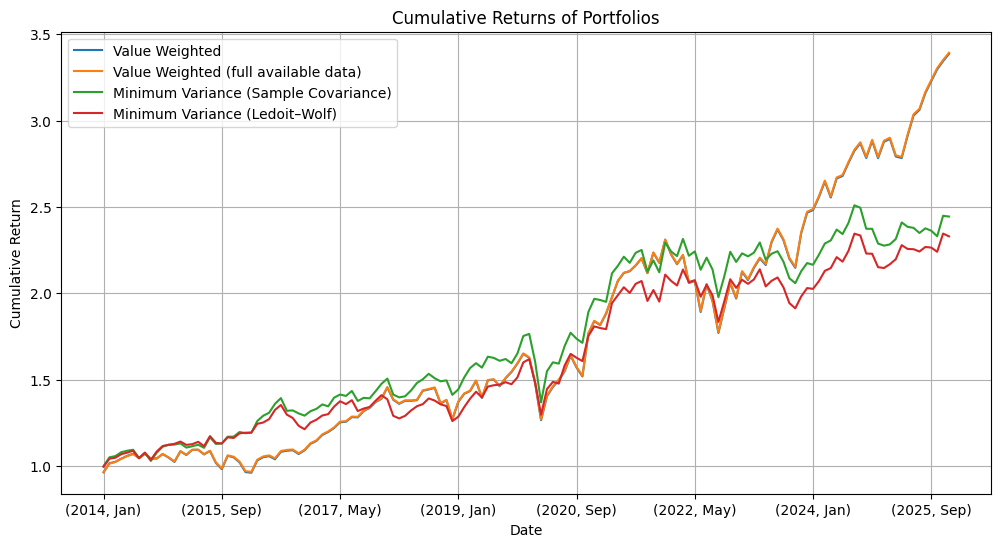

In [80]:
# Creation of a new portfolio that contains the cumulative returns in separate columns with dates as index to be able to plot them
cumulative_returns_df = pd.DataFrame({
    'Value Weighted': (1 + comparison_returns_df['Value Weighted']).cumprod(),
    'Value Weighted (full available data)': (1 + comparison_returns_df['Value Weighted (full available data)']).cumprod(),
    'Minimum Variance (Sample Covariance)': (1 + comparison_returns_df['Minimum Variance (Sample Covariance)']).cumprod(),
    'Minimum Variance (Ledoit–Wolf)': (1 + comparison_returns_df['Minimum Variance (Ledoit–Wolf)']).cumprod()
})
cumulative_returns_df.plot(figsize=(12, 6), title='Cumulative Returns of Portfolios', ylabel='Cumulative Return', xlabel='Date')
plt.legend(loc='upper left')
plt.grid()
plt.show()

### Full Investment Sets

In [81]:
# Get the investment sets for each year
# Each of them contains the market value weights of the stocks for the value-weighted portfolio
for year in range(2013, 2025):
    globals()[f'inv_set_{year}'] = globals()[f'is_{year}'].copy()
# Addition of a "min_var_weight column" for weights of the minimum variance portfolio with SLSQP method
    globals()[f'inv_set_{year}']['min_var_weight_slsqp'] = globals()[f'min_var_weights_{year}_slsqp']
    # Set it as the 7th column
    cols = globals()[f'inv_set_{year}'].columns.tolist()
    cols.insert(6, cols.pop(cols.index('min_var_weight_slsqp')))
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'][cols]
# Same for the minimum variance portfolio with Ledoit–Wolf shrinkage estimator
    globals()[f'lw_weights_{year}'] = globals()[f'min_var_portfolio_{year}_lw'].copy()
    
    # Merge its dataframe with inv_set_{year} on the ISIN column to have all the data in one dataframe
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'].merge(globals()[f'lw_weights_{year}'], on='ISIN', how='left')

    # Rename the "min_var_weight" column to "min_var_weight_lw" to differentiate it from the SLSQP weights
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'].rename(columns={'min_var_weight': 'min_var_weight_lw'})
    
    # set the "min_var_weight_lw" column as the 8th column
    cols = list(globals()[f'inv_set_{year}'].columns)
    cols.insert(7, cols.pop(cols.index("min_var_weight_lw")))
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'][cols]

    # set all the NAs or NaNs in the "min_var_weight_lw" column to zero
    globals()[f'inv_set_{year}']["min_var_weight_lw"] = globals()[f'inv_set_{year}']["min_var_weight_lw"].fillna(0)

 # Recalculate the weights for the value-weighted portfolio with full available data   
    # copy the is_yyyy_fa dataframe to a new dataframe with only the ISIN and MV_Y_weight columns
    globals()[f'inv_set_{year}_fa'] = globals()[f'is_{year}_fa'][['ISIN', 'MV_Y_weight']].copy()
    # Renormalize the weights to sum to 1
    globals()[f'inv_set_{year}_fa']['MV_Y_weight'] /= globals()[f'inv_set_{year}_fa']['MV_Y_weight'].sum()
    # Rename the "MV_Y_weight" column to "MV_Y_weight_fa" to differentiate it from the original weights
    globals()[f'inv_set_{year}_fa'] = globals()[f'inv_set_{year}_fa'].rename(columns={'MV_Y_weight': 'MV_Y_weight_fa'})
    # Merge this dataframe with inv_set_{year} on the ISIN column to have all the data in one dataframe
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'].merge(globals()[f'inv_set_{year}_fa'], on='ISIN', how='left')
    # set the "MV_Y_weight_fa" column as the 7th column
    cols = list(globals()[f'inv_set_{year}'].columns)
    cols.insert(6, cols.pop(cols.index("MV_Y_weight_fa")))
    globals()[f'inv_set_{year}'] = globals()[f'inv_set_{year}'][cols]
    # set all the NAs or NaNs in the "MV_Y_weight_fa" column to zero
    globals()[f'inv_set_{year}']["MV_Y_weight_fa"] = globals()[f'inv_set_{year}']["MV_Y_weight_fa"].fillna(0)
    
inv_set_2013

,ISIN,NAME,Country,Region,MV_Y,MV_Y_weight,MV_Y_weight_fa,min_var_weight_slsqp,min_var_weight_lw,CO2_S1,...,2013-03-29 00:00:00,2013-04-30 00:00:00,2013-05-31 00:00:00,2013-06-28 00:00:00,2013-07-31 00:00:00,2013-08-30 00:00:00,2013-09-30 00:00:00,2013-10-31 00:00:00,2013-11-29 00:00:00,2013-12-31 00:00:00
0,AN8068571086,SLB,US,AMER,105861.90,0.005598,0.005821,0.000000e+00,3.557755e-22,1790000.0,...,-0.0380,-0.0061,-0.0188,-0.0146,0.1349,-0.0010,0.0917,0.0607,-0.0566,0.0227
1,AT000000STR1,STRABAG SE,AT,EUR,3087.59,0.000163,0.000000,1.733160e-18,0.000000e+00,968759.0,...,-0.0889,0.0266,-0.0669,-0.0270,0.0828,-0.0430,0.1655,0.0549,0.1161,-0.0004
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR,8185.61,0.000433,0.000000,0.000000e+00,0.000000e+00,5161.0,...,-0.1008,0.0375,-0.0315,-0.1490,0.1007,0.1284,-0.0434,0.1239,0.0031,-0.0436
3,AT0000652011,ERSTE GROUP BANK,AT,EUR,13245.36,0.000700,0.000728,8.605859e-19,2.131335e-21,32753.0,...,-0.1350,0.1245,0.0511,-0.1794,0.1433,0.0550,-0.0113,0.1167,-0.0010,-0.0106
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR,3381.96,0.000179,0.000186,1.098636e-18,3.834458e-22,27476.0,...,-0.0064,0.0442,-0.0014,-0.0686,0.0974,0.0339,0.1697,-0.0169,0.0330,-0.1099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,US98389B1008,XCEL ENERGY,US,AMER,13656.38,0.000722,0.000751,6.017023e-05,0.000000e+00,56535330.0,...,0.0446,0.0704,-0.0966,-0.0038,0.0568,-0.0678,-0.0009,0.0453,-0.0291,0.0071
799,US9839191015,XILINX DEAD - DELIST.15/02/22,US,AMER,9719.62,0.000514,0.000534,4.918216e-19,3.184997e-22,1685.0,...,0.0241,-0.0068,0.0794,-0.0256,0.1787,-0.0650,0.0790,-0.0304,-0.0166,0.0335
800,US98421M1062,XEROX HOLDINGS,US,AMER,9815.17,0.000519,0.000540,2.111845e-18,9.881284e-22,127000.0,...,0.0675,-0.0023,0.0245,0.0385,0.0695,0.0289,0.0367,-0.0340,0.1449,0.0744
801,US9884981013,YUM! BRANDS,US,AMER,29787.74,0.001575,0.001638,0.000000e+00,3.978925e-22,156510.0,...,0.0987,-0.0483,-0.0054,0.0235,0.0565,-0.0398,0.0196,-0.0475,0.1488,-0.0267


In [82]:
# Store all the investment sets with associated weights in csv files
for year in range(2013, 2025):
    globals()[f'inv_set_{year}'].to_csv(f'inv_set_{year}.csv', index=False)



### Plots

In [83]:
# Open the csv files to continue working on the inv_sets without having to re-run the whole code above
for year in range(2013, 2025):
    globals()[f'inv_set_{year}'] = pd.read_csv(f'inv_set_{year}.csv')   

inv_set_2013

,ISIN,NAME,Country,Region,MV_Y,MV_Y_weight,MV_Y_weight_fa,min_var_weight_slsqp,min_var_weight_lw,CO2_S1,...,2013-03-29 00:00:00,2013-04-30 00:00:00,2013-05-31 00:00:00,2013-06-28 00:00:00,2013-07-31 00:00:00,2013-08-30 00:00:00,2013-09-30 00:00:00,2013-10-31 00:00:00,2013-11-29 00:00:00,2013-12-31 00:00:00
0,AN8068571086,SLB,US,AMER,105861.90,0.005598,0.005821,0.000000e+00,3.557755e-22,1790000.0,...,-0.0380,-0.0061,-0.0188,-0.0146,0.1349,-0.0010,0.0917,0.0607,-0.0566,0.0227
1,AT000000STR1,STRABAG SE,AT,EUR,3087.59,0.000163,0.000000,1.733160e-18,0.000000e+00,968759.0,...,-0.0889,0.0266,-0.0669,-0.0270,0.0828,-0.0430,0.1655,0.0549,0.1161,-0.0004
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR,8185.61,0.000433,0.000000,0.000000e+00,0.000000e+00,5161.0,...,-0.1008,0.0375,-0.0315,-0.1490,0.1007,0.1284,-0.0434,0.1239,0.0031,-0.0436
3,AT0000652011,ERSTE GROUP BANK,AT,EUR,13245.36,0.000700,0.000728,8.605859e-19,2.131335e-21,32753.0,...,-0.1350,0.1245,0.0511,-0.1794,0.1433,0.0550,-0.0113,0.1167,-0.0010,-0.0106
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR,3381.96,0.000179,0.000186,1.098636e-18,3.834458e-22,27476.0,...,-0.0064,0.0442,-0.0014,-0.0686,0.0974,0.0339,0.1697,-0.0169,0.0330,-0.1099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,US98389B1008,XCEL ENERGY,US,AMER,13656.38,0.000722,0.000751,6.017023e-05,0.000000e+00,56535330.0,...,0.0446,0.0704,-0.0966,-0.0038,0.0568,-0.0678,-0.0009,0.0453,-0.0291,0.0071
799,US9839191015,XILINX DEAD - DELIST.15/02/22,US,AMER,9719.62,0.000514,0.000534,4.918216e-19,3.184997e-22,1685.0,...,0.0241,-0.0068,0.0794,-0.0256,0.1787,-0.0650,0.0790,-0.0304,-0.0166,0.0335
800,US98421M1062,XEROX HOLDINGS,US,AMER,9815.17,0.000519,0.000540,2.111845e-18,9.881284e-22,127000.0,...,0.0675,-0.0023,0.0245,0.0385,0.0695,0.0289,0.0367,-0.0340,0.1449,0.0744
801,US9884981013,YUM! BRANDS,US,AMER,29787.74,0.001575,0.001638,0.000000e+00,3.978925e-22,156510.0,...,0.0987,-0.0483,-0.0054,0.0235,0.0565,-0.0398,0.0196,-0.0475,0.1488,-0.0267


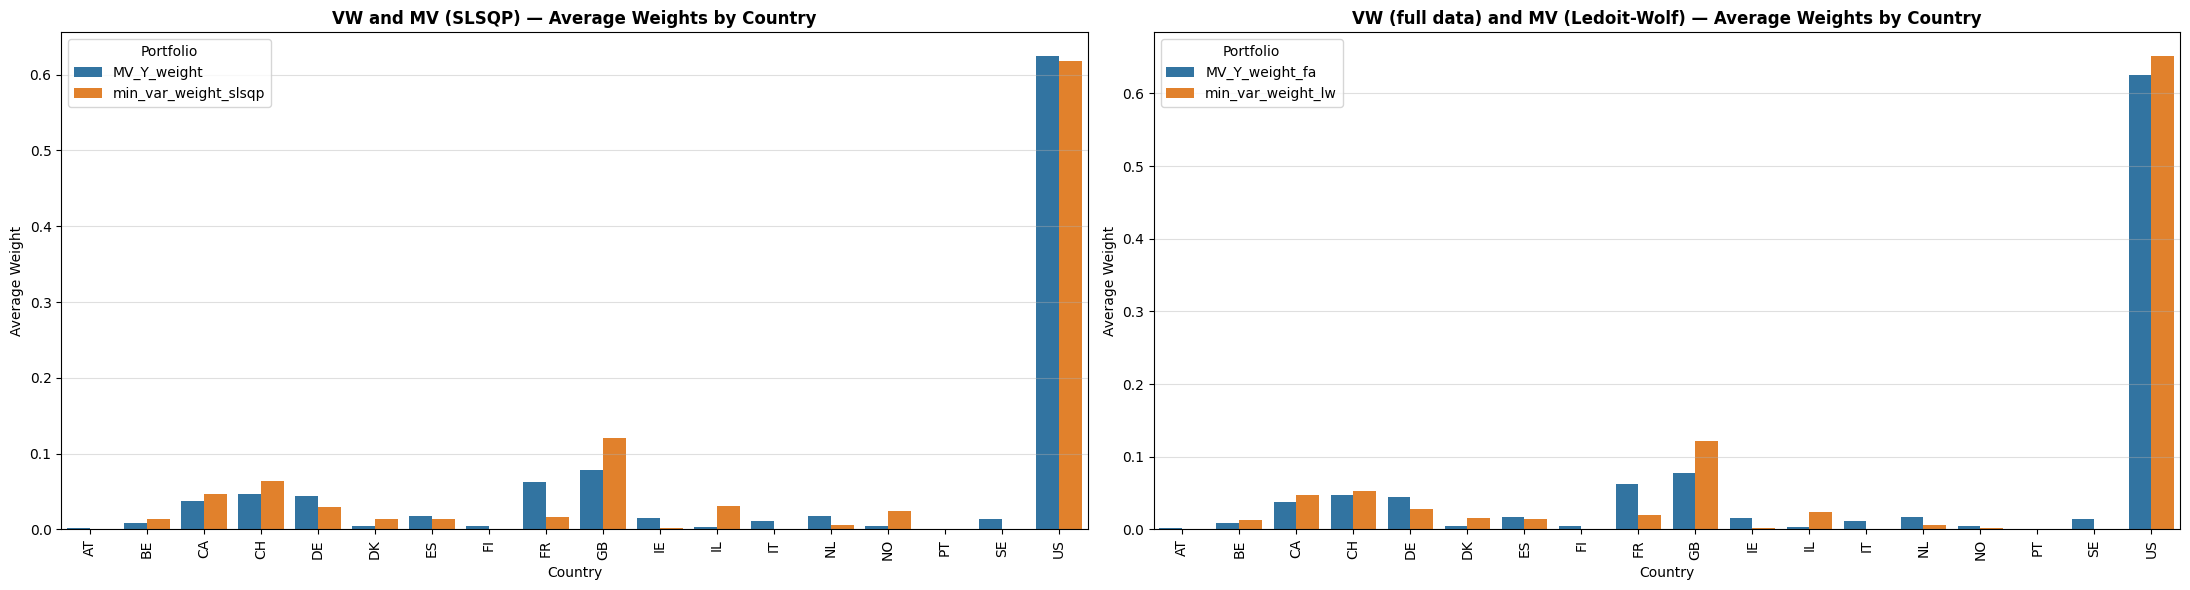

In [242]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))

# Left: VW (sample) and MV (SLSQP)
for year in range(2013, 2025):
    globals()[f'weights_by_country_{year}'] = globals()[f'inv_set_{year}'].groupby('Country')[['MV_Y_weight', 'min_var_weight_slsqp']].sum().reset_index()
    globals()[f'weights_by_country_{year}'] = globals()[f'weights_by_country_{year}'].melt(id_vars='Country', var_name='Portfolio', value_name='Weight')
weights_by_country_all_years = pd.concat([globals()[f'weights_by_country_{year}'] for year in range(2013, 2025)], ignore_index=True)
weights_by_country_all_years = weights_by_country_all_years.groupby(['Country', 'Portfolio'])['Weight'].mean().reset_index()
sns.barplot(data=weights_by_country_all_years, x='Country', y='Weight', hue='Portfolio', ax=ax1)
ax1.set_title('VW and MV (SLSQP) — Average Weights by Country', fontweight='bold')
ax1.set_ylabel('Average Weight'); ax1.set_xlabel('Country')
ax1.tick_params(axis='x', rotation=90); ax1.legend(title='Portfolio'); ax1.grid(axis='y', alpha=0.4)

# Right: VW (full data) and MV (Ledoit-Wolf)
for year in range(2013, 2025):
    globals()[f'weights_by_country_{year}'] = globals()[f'inv_set_{year}'].groupby('Country')[['MV_Y_weight_fa', 'min_var_weight_lw']].sum().reset_index()
    globals()[f'weights_by_country_{year}'] = globals()[f'weights_by_country_{year}'].melt(id_vars='Country', var_name='Portfolio', value_name='Weight')
weights_by_country_all_years = pd.concat([globals()[f'weights_by_country_{year}'] for year in range(2013, 2025)], ignore_index=True)
weights_by_country_all_years = weights_by_country_all_years.groupby(['Country', 'Portfolio'])['Weight'].mean().reset_index()
sns.barplot(data=weights_by_country_all_years, x='Country', y='Weight', hue='Portfolio', ax=ax2)
ax2.set_title('VW (full data) and MV (Ledoit-Wolf) — Average Weights by Country', fontweight='bold')
ax2.set_ylabel('Average Weight'); ax2.set_xlabel('Country')
ax2.tick_params(axis='x', rotation=90); ax2.legend(title='Portfolio'); ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


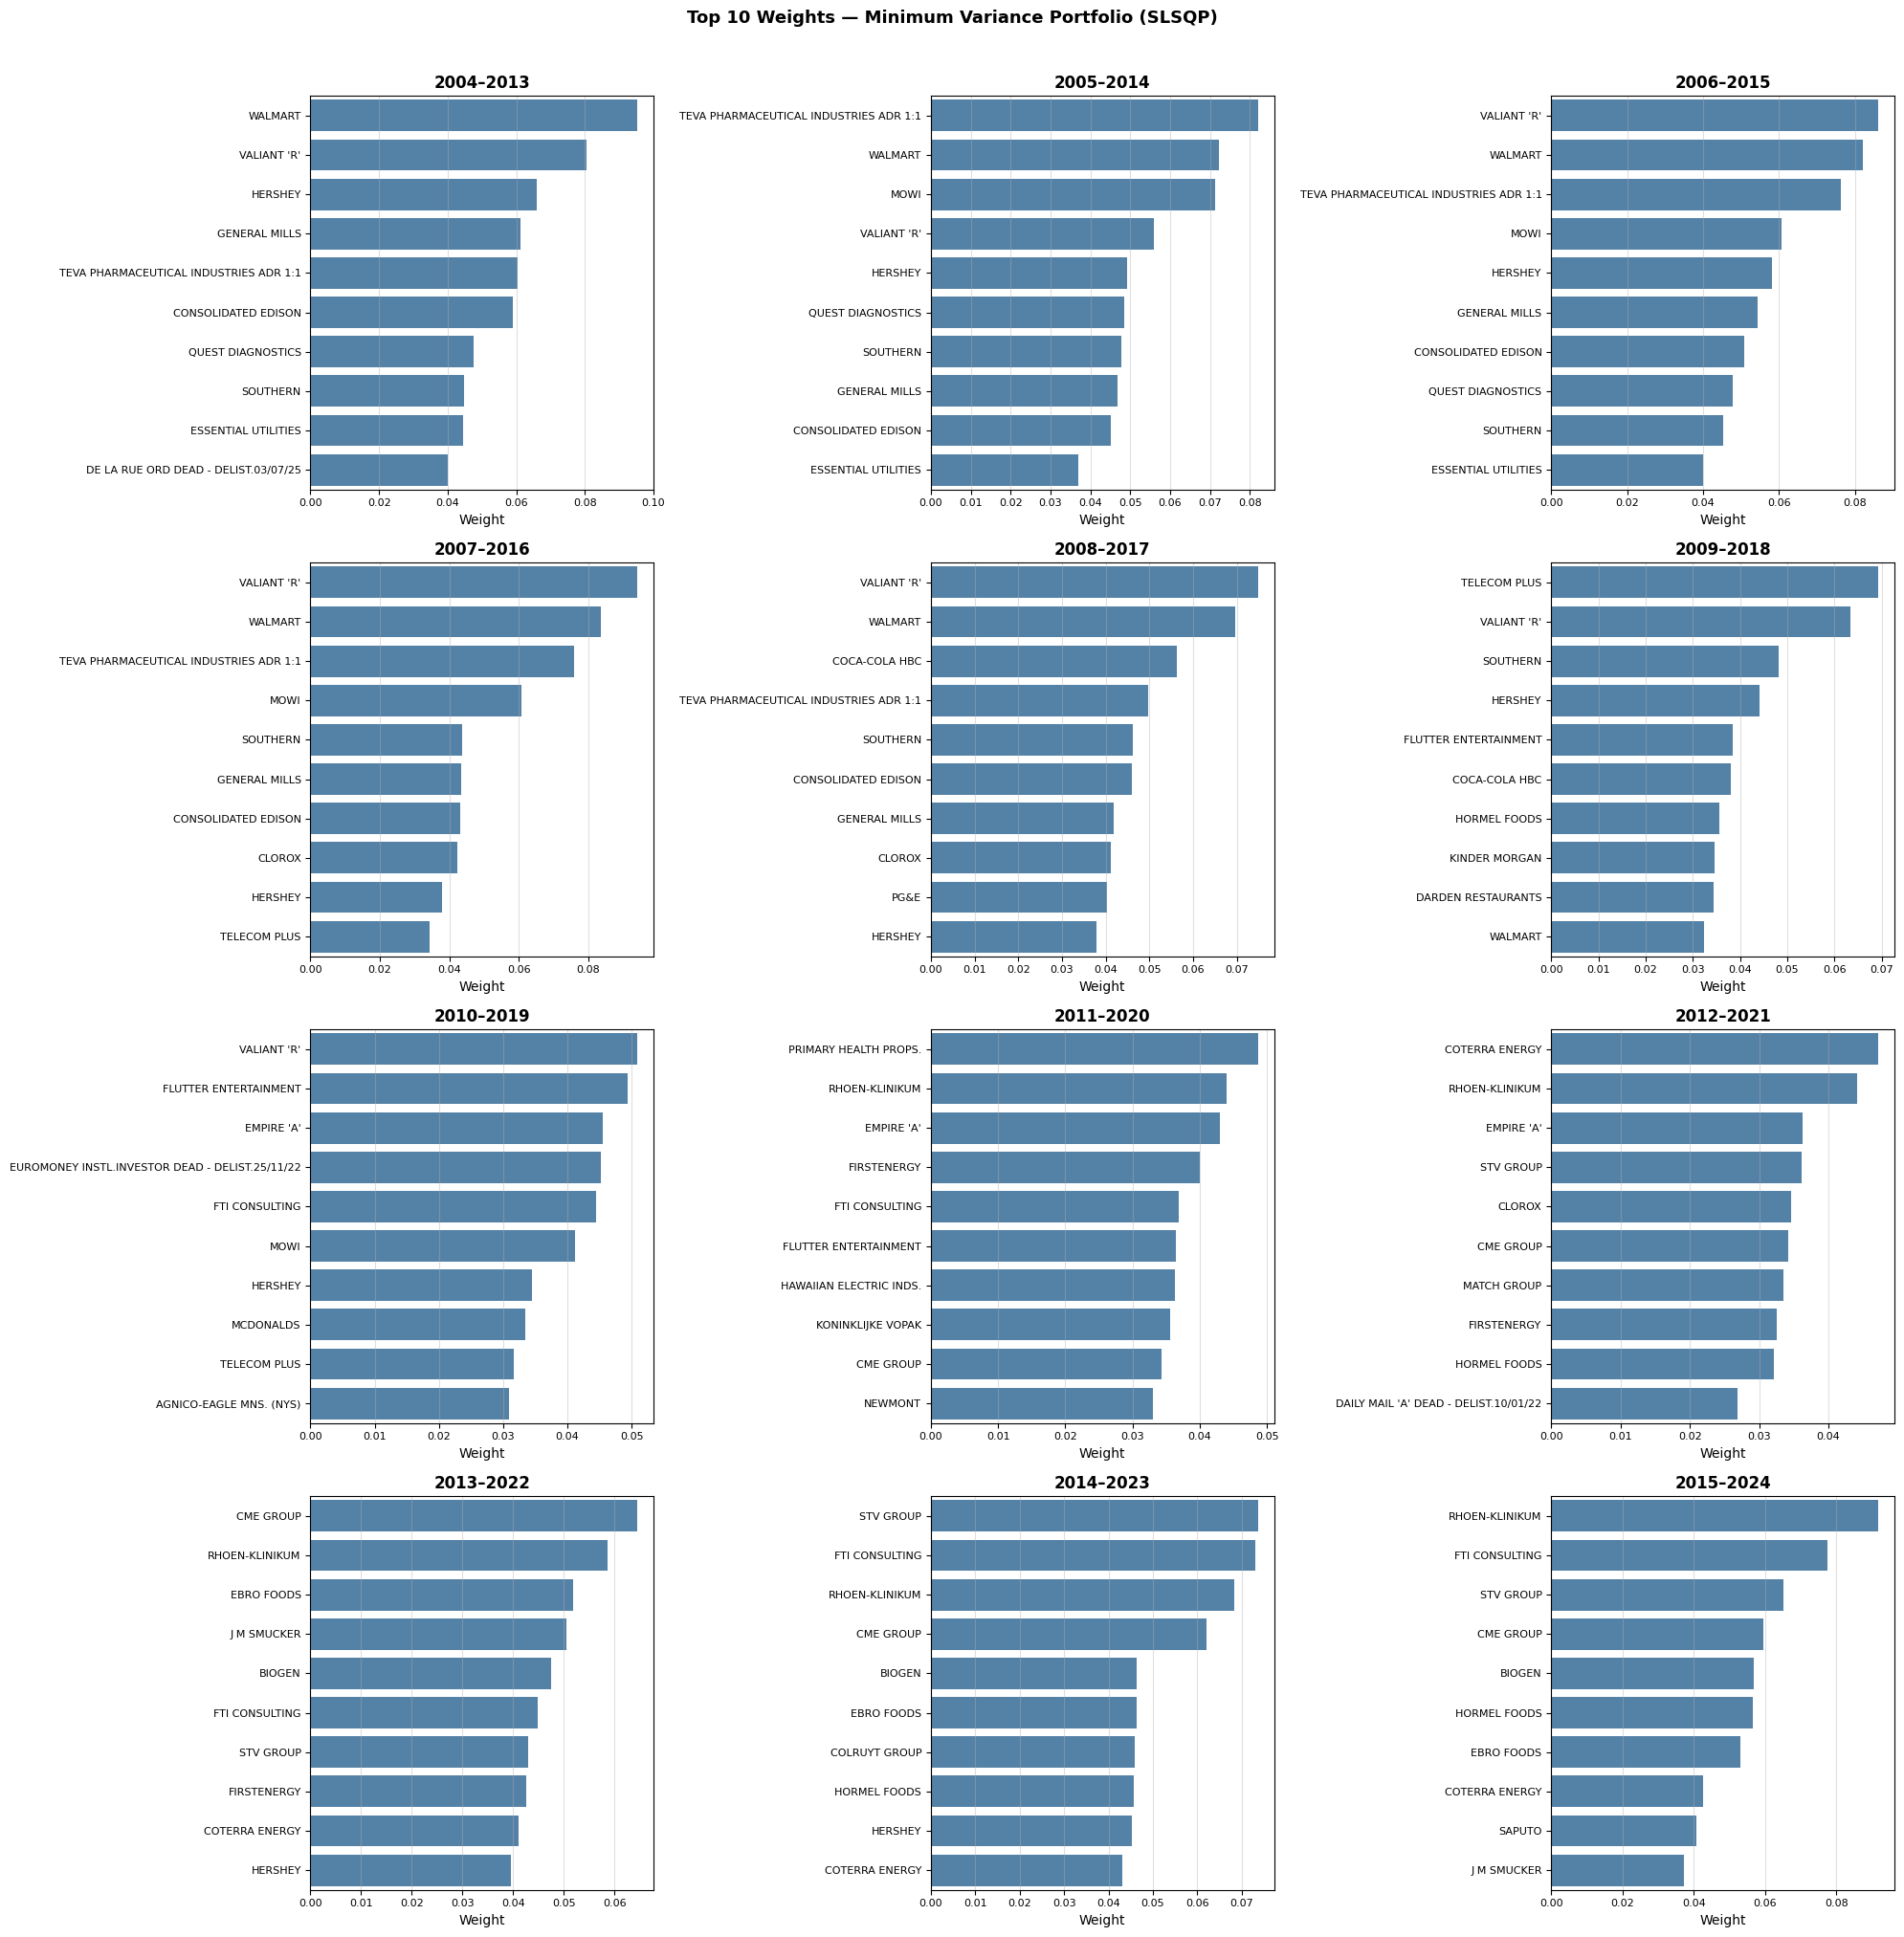

In [243]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
for ax, year in zip(axes.flatten(), range(2013, 2025)):
    top10 = globals()[f'inv_set_{year}'].nlargest(10, 'min_var_weight_slsqp')[['NAME', 'min_var_weight_slsqp']]
    sns.barplot(data=top10, x='min_var_weight_slsqp', y='NAME', ax=ax, color='steelblue')
    ax.set_title(f'{year-9}–{year}', fontweight='bold')
    ax.set_xlabel('Weight'); ax.set_ylabel('')
    ax.tick_params(labelsize=8); ax.grid(axis='x', alpha=0.4)
fig.suptitle('Top 10 Weights — Minimum Variance Portfolio (SLSQP)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


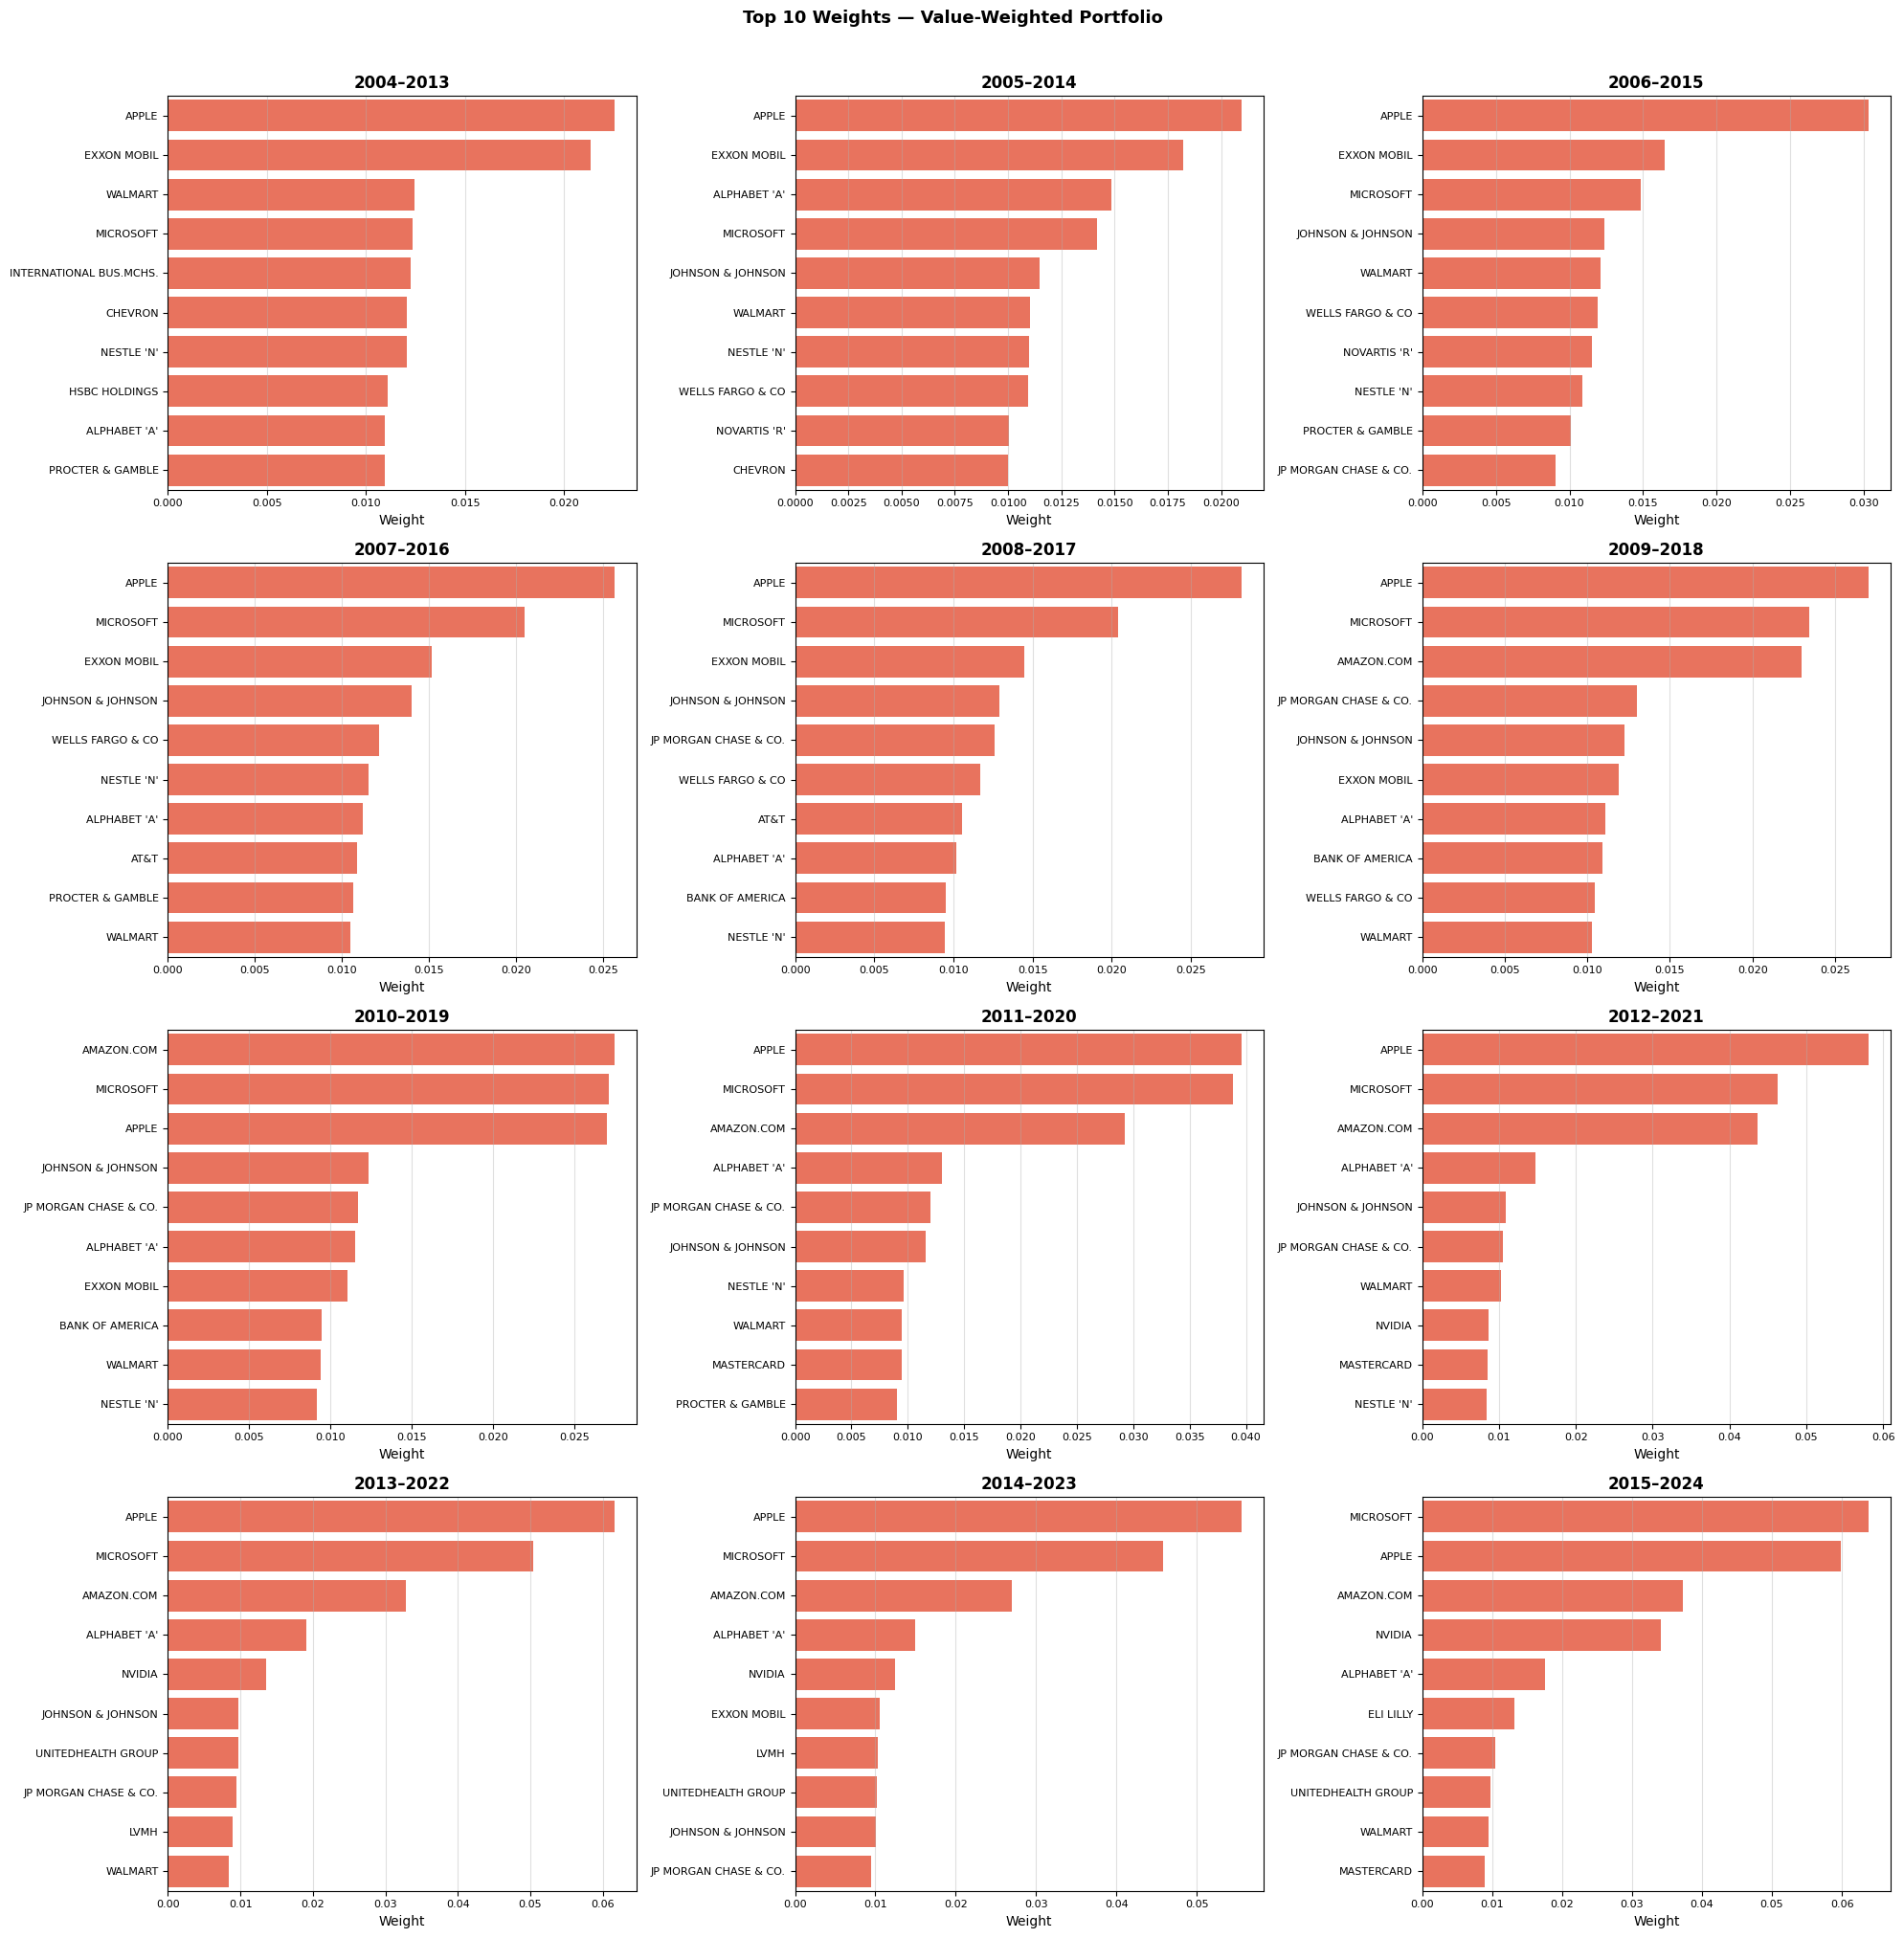

In [244]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
for ax, year in zip(axes.flatten(), range(2013, 2025)):
    top10 = globals()[f'inv_set_{year}'].nlargest(10, 'MV_Y_weight')[['NAME', 'MV_Y_weight']]
    sns.barplot(data=top10, x='MV_Y_weight', y='NAME', ax=ax, color='tomato')
    ax.set_title(f'{year-9}–{year}', fontweight='bold')
    ax.set_xlabel('Weight'); ax.set_ylabel('')
    ax.tick_params(labelsize=8); ax.grid(axis='x', alpha=0.4)
fig.suptitle('Top 10 Weights — Value-Weighted Portfolio', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Allocation with a 50% Reduction in Carbon Emissions

### Computation of the Weighted Average Carbon Intensities of both Value-Weighted Portfolios 

In [88]:
# Print the carbon intensity of Exxon Mobil on 2019 to verify it is correctly calculated
# Should be around 470 tonnes of CO2 per million dollars of revenue according to Trucost(2021), found in the slides of lecture 6
exxon_ci_2019 = globals()[f'inv_set_2019'][globals()[f'inv_set_2019']['NAME'] == 'EXXON MOBIL']['CI'].values
print("Exxon Mobil's Carbon Intensity in 2019:", exxon_ci_2019)

Exxon Mobil's Carbon Intensity in 2019: [393.7966]


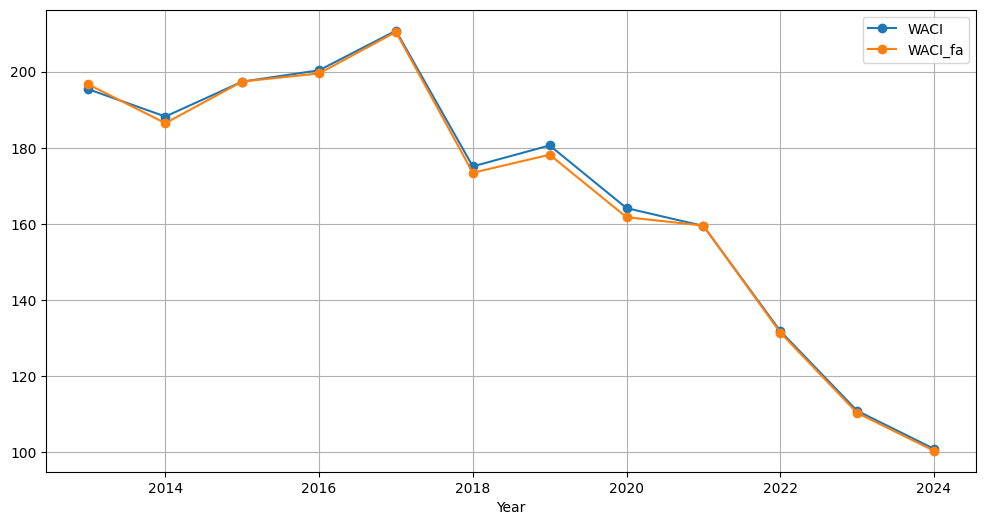

,Year,WACI,WACI_fa
0,2013,195.365102,196.625223
1,2014,188.198075,186.458265
2,2015,197.364990,197.399460
3,2016,200.352234,199.531131
4,2017,210.753657,210.445129
5,2018,175.096197,173.422871
6,2019,180.602748,178.169369
7,2020,164.134029,161.742504
8,2021,159.441901,159.538445
9,2022,131.831835,131.435244


In [240]:
# WACI for the value-weighted portfolio for each year
for year in range(2013, 2025):
    globals()[f'waci_{year}_vw'] = (globals()[f'inv_set_{year}']['MV_Y_weight'] * globals()[f'inv_set_{year}']['CI']).sum()
    # Arrange the WACI values in a dataframe to be able to plot them
    globals()[f'waci_df_{year}_vw'] = pd.DataFrame({
        'Year': [year],
        'WACI': [globals()[f'waci_{year}_vw']]
    })
waci_vw_df = pd.concat([globals()[f'waci_df_{year}_vw'] for year in range(2013, 2025)], ignore_index=True)

# Same for the value-weighted portfolio with full available data
# WACI for the value-weighted portfolio with full data for each year
for year in range(2013, 2025):
    globals()[f'waci_{year}_vw_fa'] = (globals()[f'inv_set_{year}']['MV_Y_weight_fa'] * globals()[f'inv_set_{year}']['CI']).sum()
    # Arrange the WACI values in a dataframe to be able to plot them
    globals()[f'waci_df_{year}_vw_fa'] = pd.DataFrame({
        'Year': [year],
        'WACI_fa': [globals()[f'waci_{year}_vw_fa']]
    })
waci_vw_fa_df = pd.concat([globals()[f'waci_df_{year}_vw_fa'] for year in range(2013, 2025)], ignore_index=True)

# Merge both dataframes on Year to be able to compare the WACI of the value-weighted portfolio with and without full available data
WACI_vw_df = waci_vw_df.merge(waci_vw_fa_df, on='Year')

# Plot the WACI of the value-weighted portfolio with and without full available data to compare them
WACI_vw_df.plot(x='Year', y=['WACI', 'WACI_fa'], figsize = (12,6), marker='o')
plt.grid()
plt.show()

WACI_vw_df


### Computation of the Carbon Footprint of both Value-Weighted Portfolios

In [203]:
# Starting with an initial wealth Wo of 1 million dollars,
# we can calculate the starting wealth Ws for each year as : 
# Wyyyy = Wyyyy-1 * (1 + cumulative return over the year).
W0 = 1000000

# Computation of annual cumulative returns
cumulative_returns_calculation = comparison_returns_df.copy()
cumulative_returns_calculation = cumulative_returns_calculation.reset_index().rename(columns={'level_0': 'Year'}).rename(columns={'level_1': 'Month'})
# Group the data by year
grouped = cumulative_returns_calculation.groupby('Year')

for year in range (2014,2026):
    globals()[f'cumulative_returns_calculation_{year}'] = grouped.get_group(year)
    globals()[f'cumulative_returns_calculation_{year}'] = globals()[f'cumulative_returns_calculation_{year}'].reset_index(drop=True)
    globals()[f'cumulative_returns_calculation_{year}'] = globals()[f'cumulative_returns_calculation_{year}'].drop(['Year', 'Month'], axis=1)

for year in range(2014, 2026):
    # Get the cumulative returns DataFrame for the current year
    df_year = globals()[f'cumulative_returns_calculation_{year}']

    # Initialize a dictionary for the current year's results
    annualized_cumulative_returns = {}

    # Calculate annualized cumulative returns for each column
    for column in df_year.columns:
        cumulative_return = df_year[column].add(1).cumprod().iloc[-1] - 1
        annualized_cumulative_returns[column] = {
            f'Annual Cumulative Return {year}': cumulative_return,
        }

    # Create a DataFrame for the current year and assign it to a global variable
    globals()[f'annual_cumulative_returns_{year}'] = pd.DataFrame(annualized_cumulative_returns)

for year in range (2014,2026):
        globals()[f'annual_return_factor_{year}'] = globals()[f'annual_cumulative_returns_{year}'].add(1)

# Aggregation of all the returns factors dataframes
list_annual_return_factors = []

for year in range(2014, 2026):
    name_df = f"annual_return_factor_{year}"
    group_df = globals()[name_df]  
    group_df['Year'] = year  # New column to make sure we recognize the year
    list_annual_return_factors.append(group_df)

# Concatenate vertically
annual_cumulative_returns_factors_total = pd.concat(list_annual_return_factors, axis=0, ignore_index=True)
annual_cumulative_returns_factors_total = annual_cumulative_returns_factors_total.set_index('Year')

wealth_evolution = annual_cumulative_returns_factors_total.copy()
wealth_evolution = wealth_evolution.cumprod() * W0
# Addition of the 2013 line with initial wealth
wealth_evolution.loc[2013] = 1000000
wealth_evolution.sort_index(inplace=True)
# Displaying the evolution of wealth over the years with each portfolio
wealth_evolution 

,Value Weighted,Value Weighted (full available data),Minimum Variance (Sample Covariance),Minimum Variance (Ledoit–Wolf)
Year,,,,
2013,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06
2014,1.048697e+06,1.050131e+06,1.122274e+06,1.123031e+06
2015,1.021195e+06,1.025416e+06,1.196822e+06,1.188985e+06
2016,1.128447e+06,1.132015e+06,1.317310e+06,1.251707e+06
2017,1.388806e+06,1.391437e+06,1.475521e+06,1.410012e+06
2018,1.268704e+06,1.271903e+06,1.412018e+06,1.260055e+06
2019,1.649608e+06,1.651651e+06,1.752603e+06,1.599859e+06
2020,1.838168e+06,1.840682e+06,1.967825e+06,1.808325e+06
2021,2.309464e+06,2.311385e+06,2.293300e+06,2.107879e+06


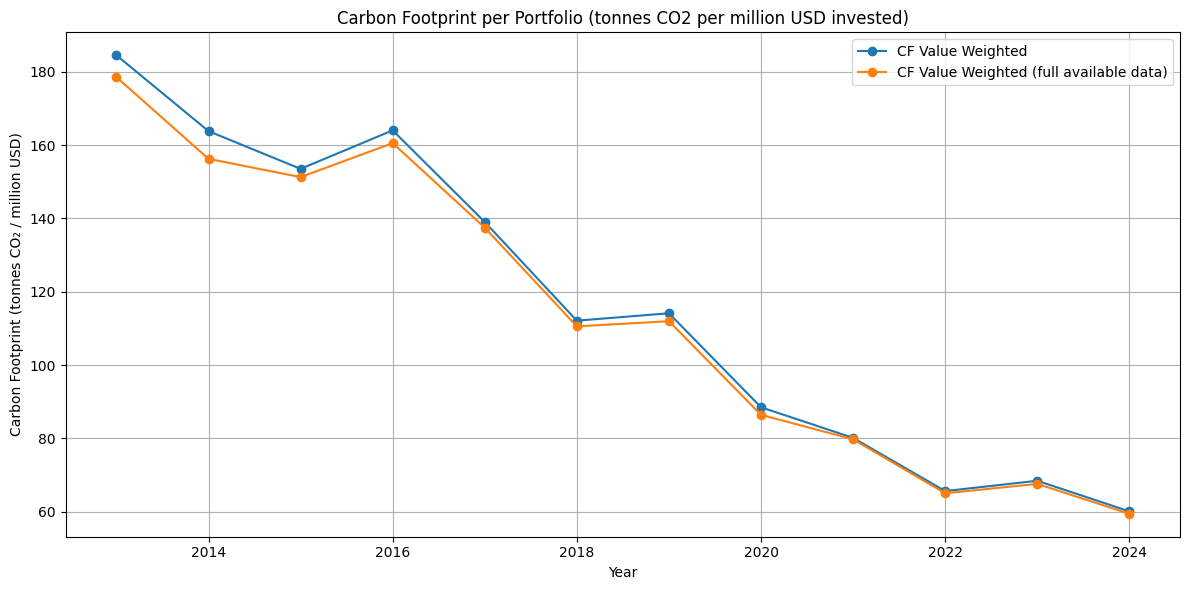

,CF Value Weighted,CF Value Weighted (full available data)
Year,,
2013,184.498567,178.539738
2014,163.803706,156.238032
2015,153.507052,151.258119
2016,164.013503,160.537842
2017,139.019640,137.454320
2018,112.098827,110.544381
2019,114.117682,111.954410
2020,88.471844,86.400814
2021,80.126854,79.737212


In [241]:
# Carbon Footprint (CF) for each portfolio, for each year Y in 2013-2024
# Formula: CF(p)_Y = sum_i [ alpha_i,Y * E_i,Y / Cap_i,Y ]
# where:
#   alpha_i,Y  = portfolio weight of firm i determined at end of year Y
#   E_i,Y      = CO2 emissions of firm i in year Y (Scope 1 + Scope 2, in tonnes)
#   Cap_i,Y    = market capitalisation of firm i at end of year Y (in million USD)
# Result is in tonnes of CO2 per million USD invested.
#
# Key point: V_Y (portfolio wealth) cancels out of the formula — CF is scale-independent.
# The weights alpha_i,Y are the ones chosen at end of Y and applied during Y+1,
# but they are evaluated against year-Y carbon data (no look-ahead bias).

cf_data = {}

for year in range(2013, 2025):
    inv = globals()[f'inv_set_{year}']
    E   = inv['CO2_S1'] + inv['CO2_S2']   # Total emissions (tonnes): Scope 1 + Scope 2
    Cap = inv['MV_Y']                        # Market capitalisation (million USD)
    cf_data[year] = {
        'CF Value Weighted':                       (inv['MV_Y_weight']          * E / Cap).sum(),
        'CF Value Weighted (full available data)': (inv['MV_Y_weight_fa']       * E / Cap).sum(),
    }

cf_df = pd.DataFrame(cf_data).T
cf_df.index.name = 'Year'

# Plot
cf_df.plot(figsize=(12, 6), marker='o',
           title='Carbon Footprint per Portfolio (tonnes CO2 per million USD invested)')
plt.ylabel('Carbon Footprint (tonnes CO₂ / million USD)')
plt.xlabel('Year')
plt.grid()
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

cf_df

### Statistics of the Carbon Footprint and Weighted Average Carbon Intensity

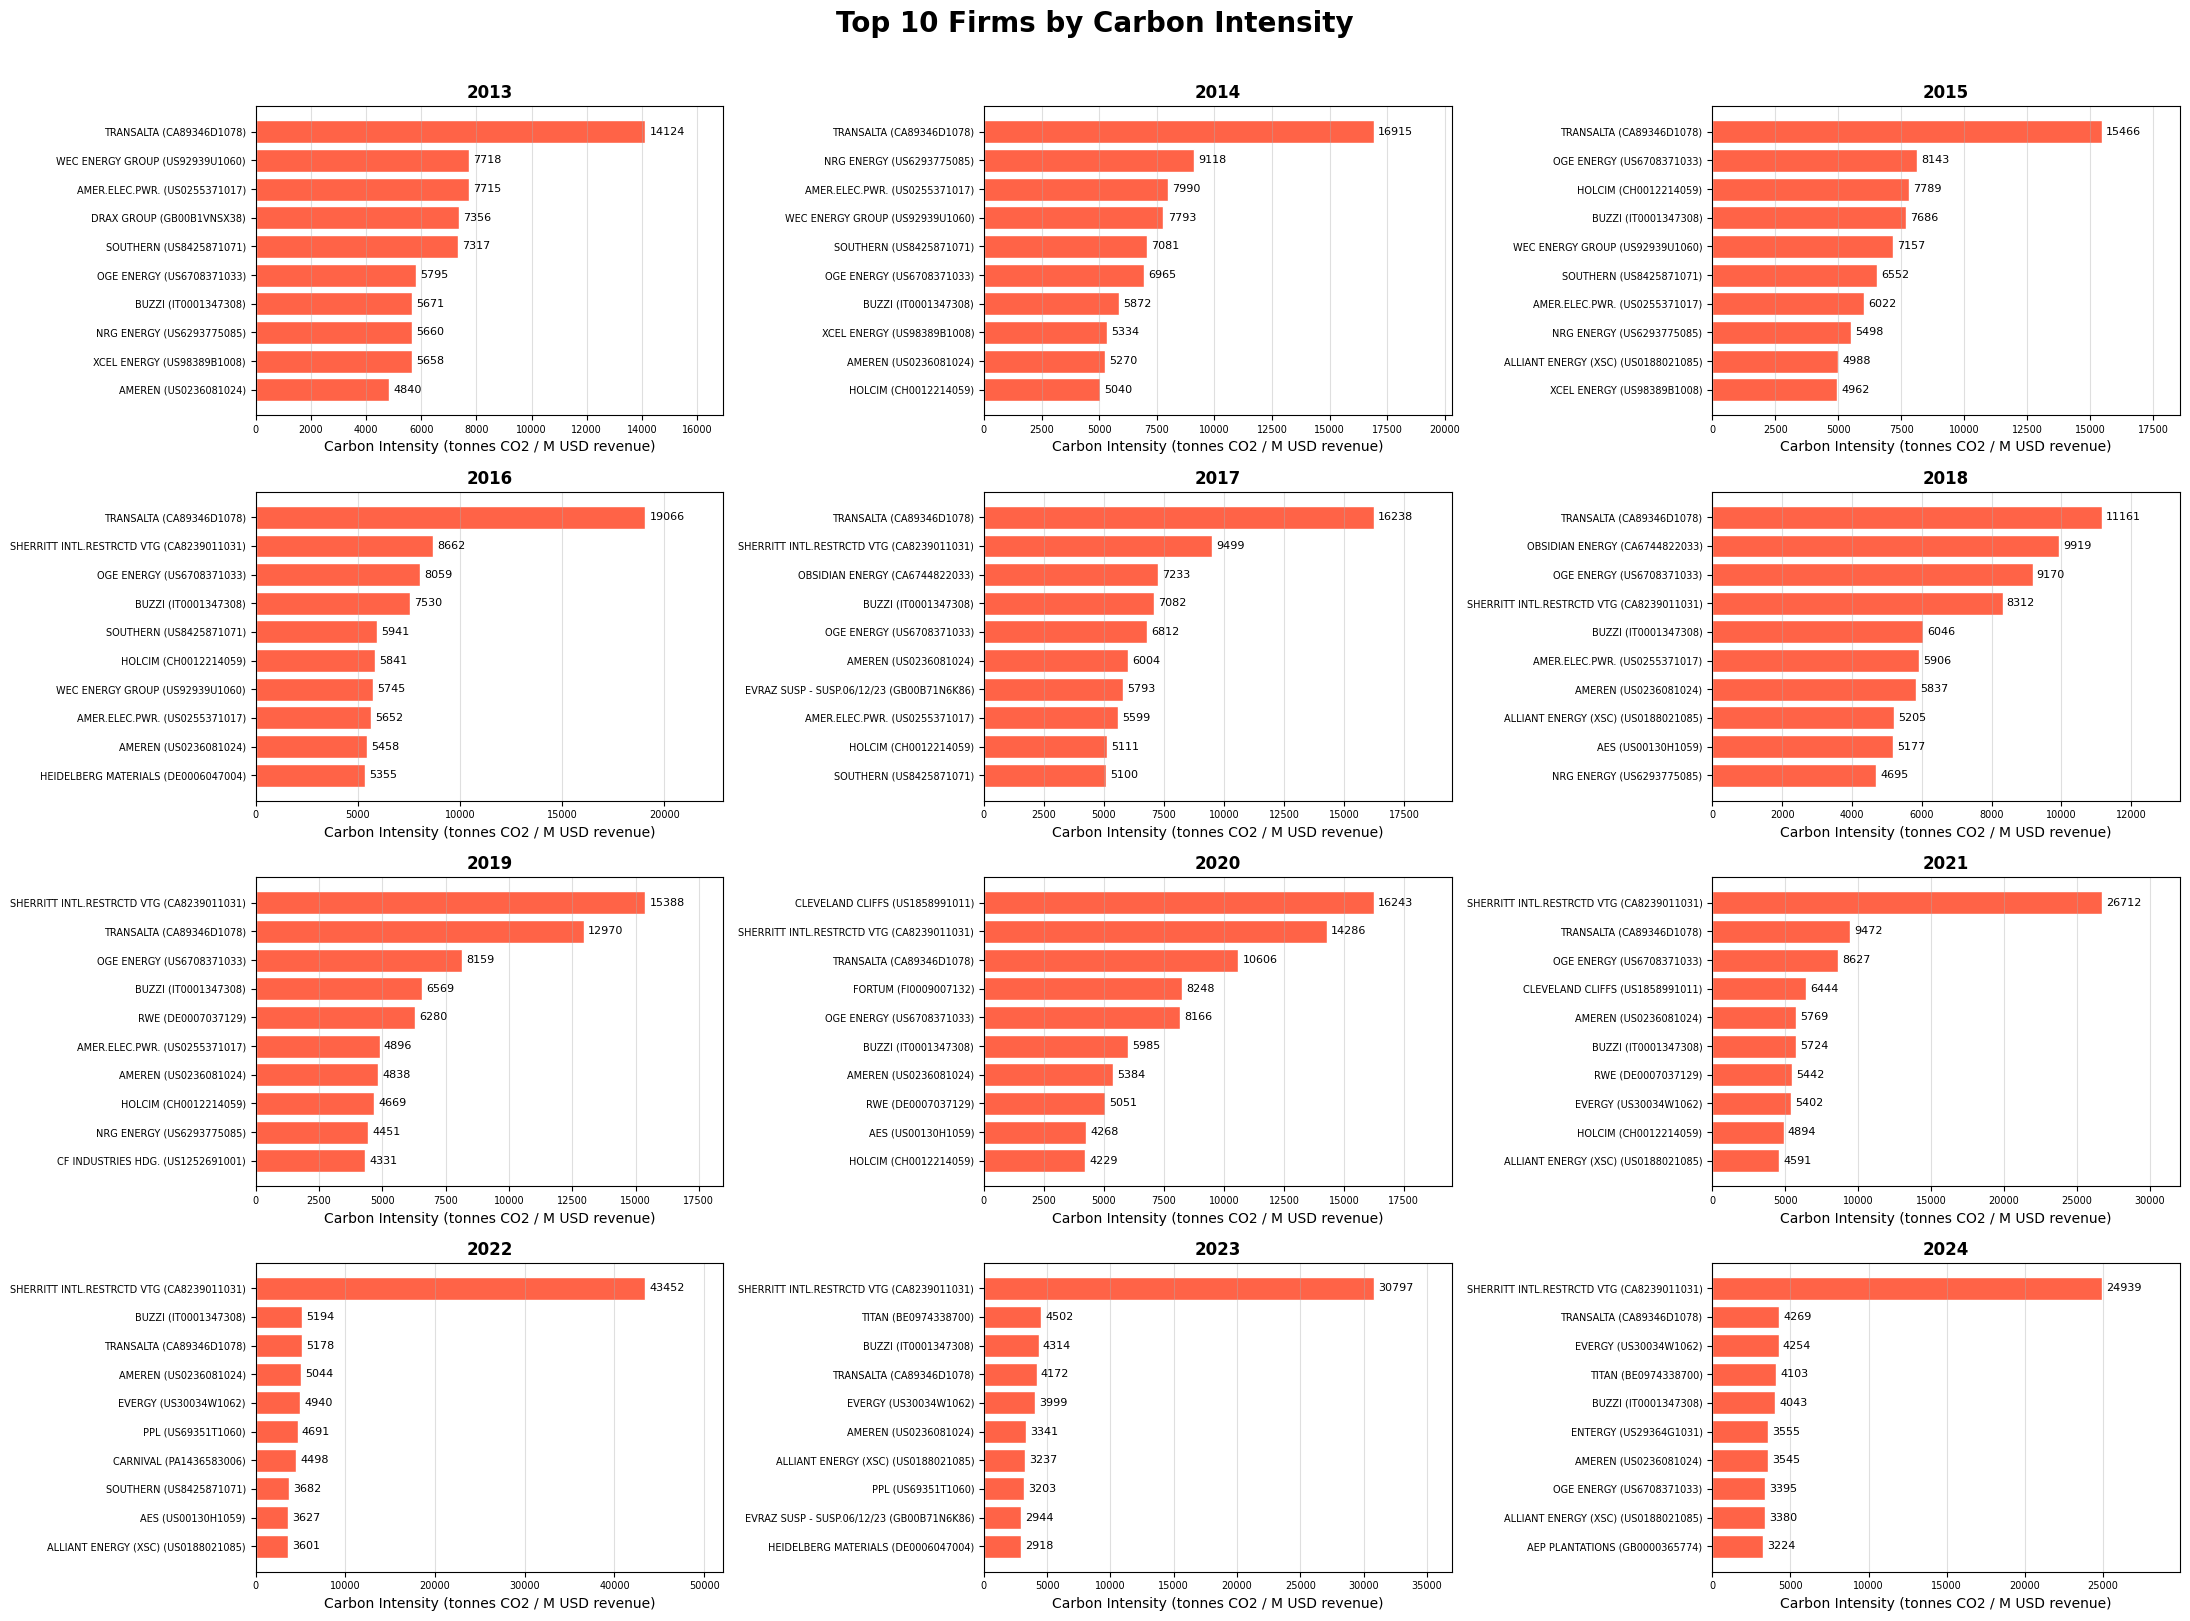

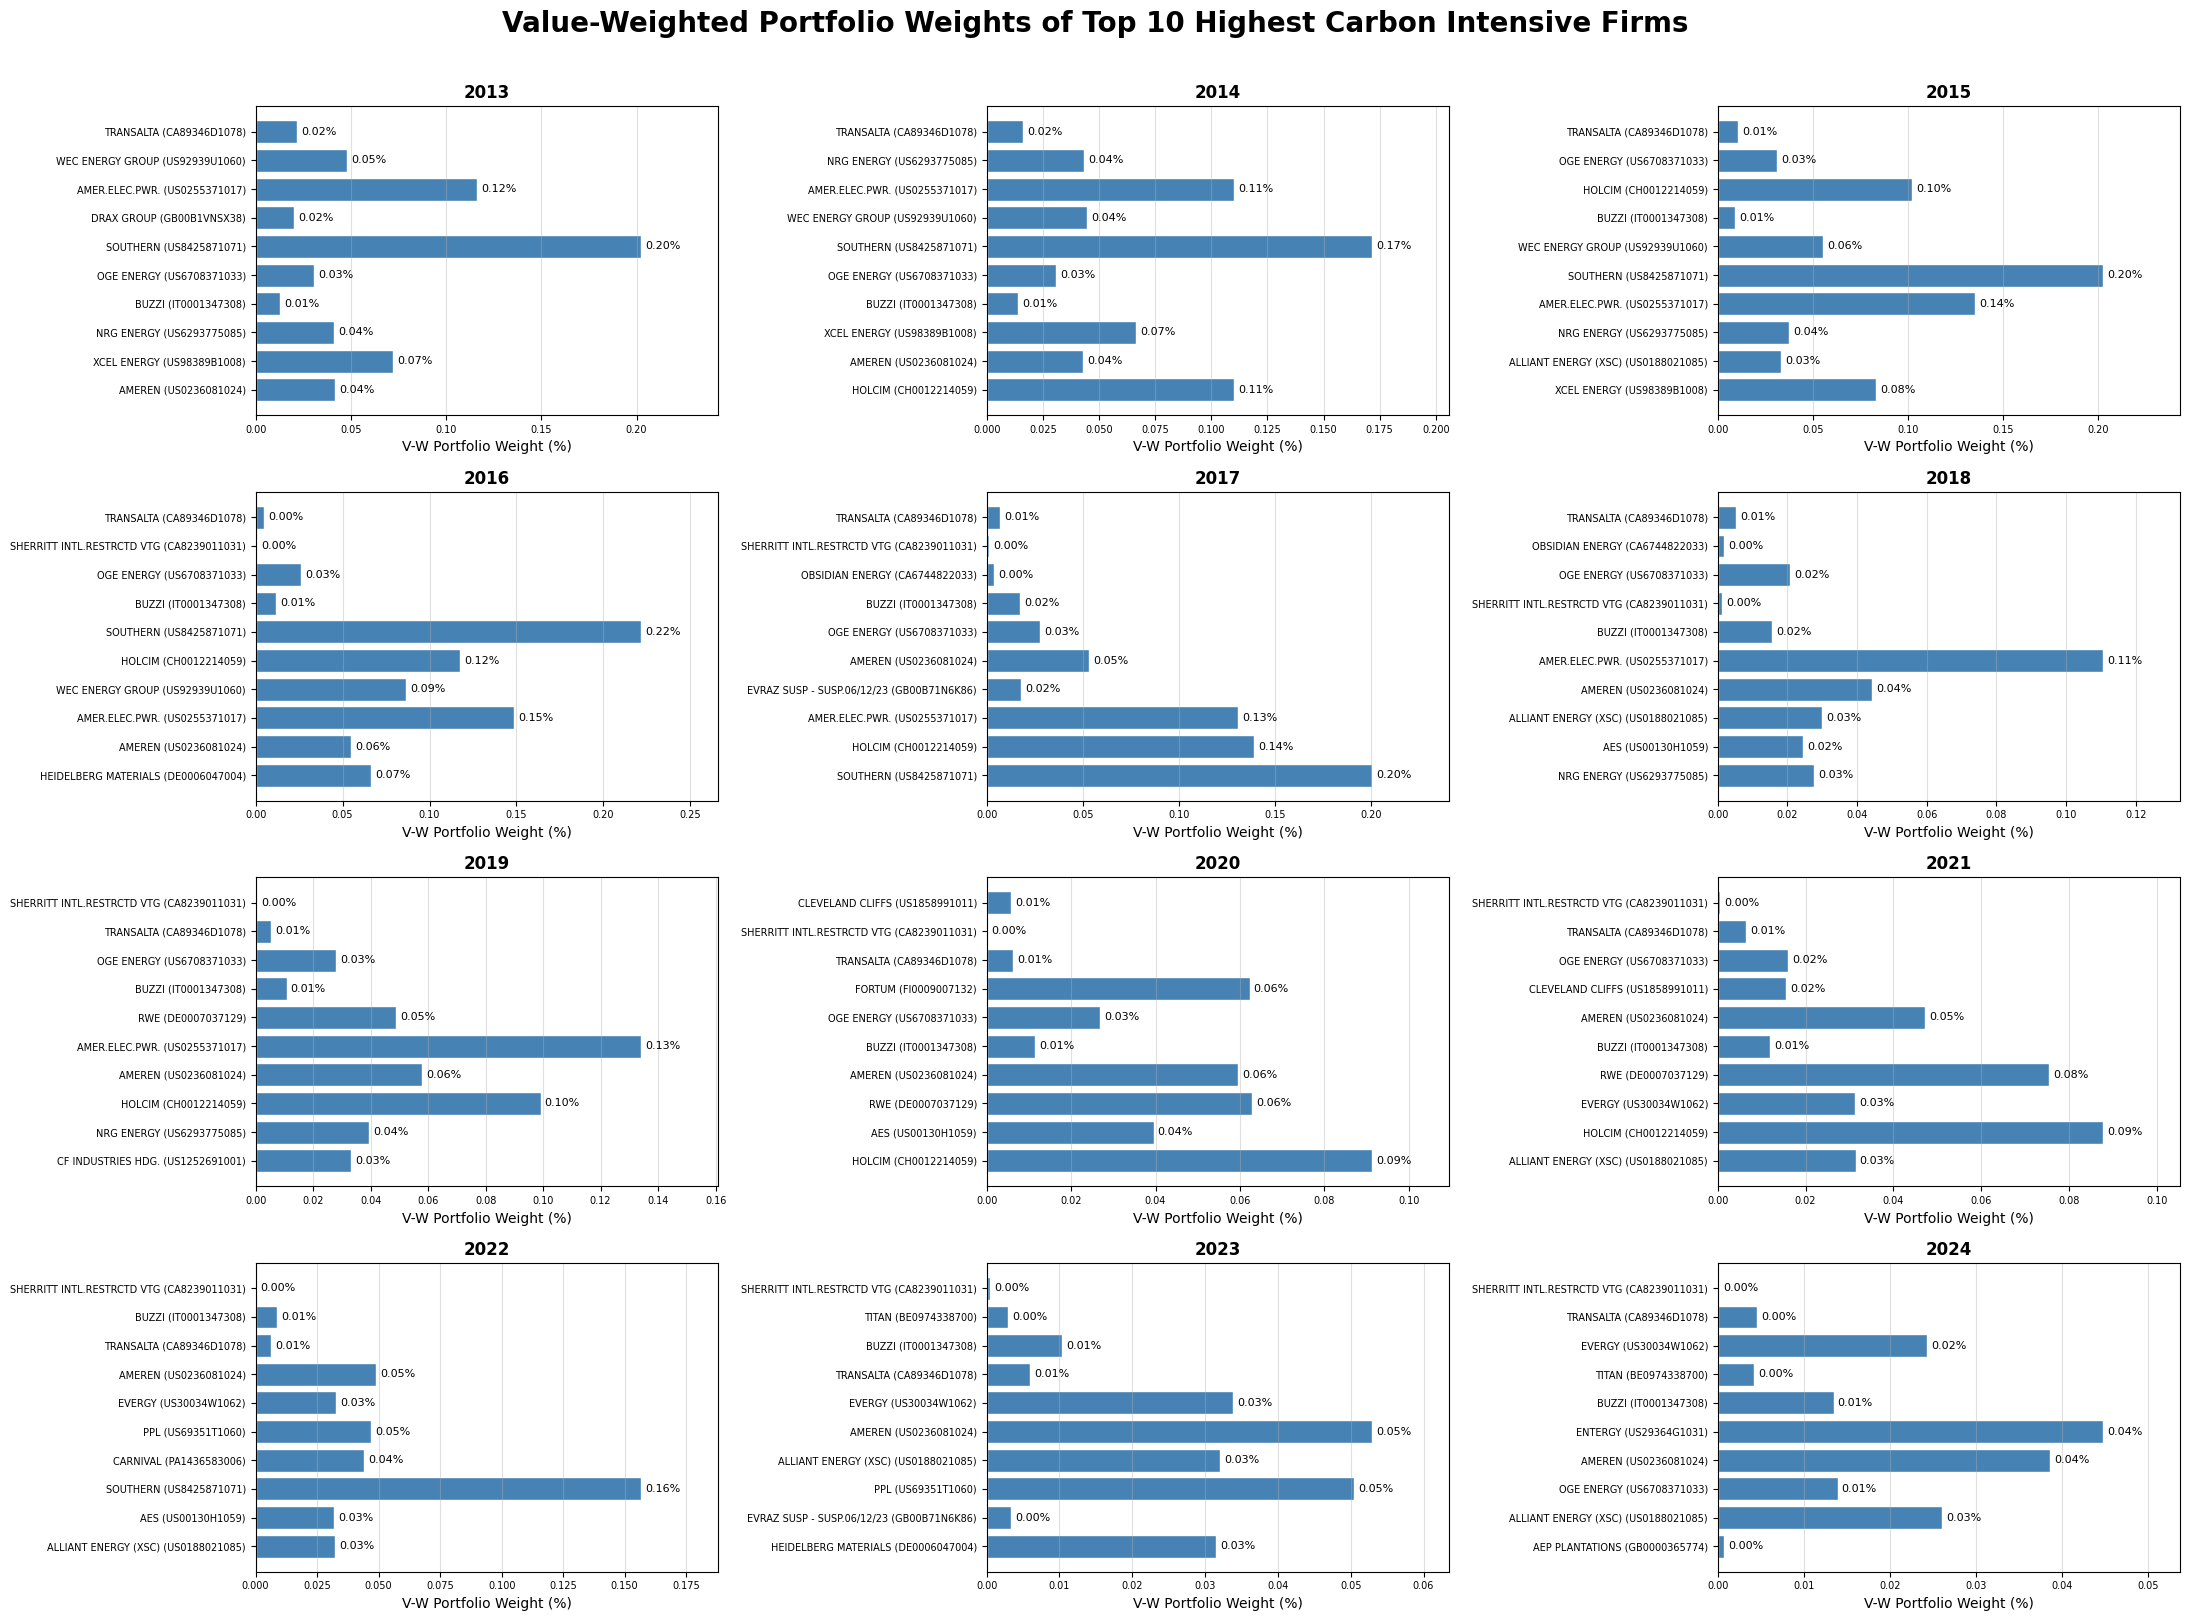

In [ ]:
# Top 10 firms by carbon intensity per year
ci_list = [] # empty list in which we will store the relevant information of CI for all the years
for year in range(2013, 2025):
    inv_set_ci = globals()[f'inv_set_{year}'][['ISIN', 'NAME', 'CI', 'MV_Y_weight']].copy()
    inv_set_ci['Year'] = year
    ci_list.append(inv_set_ci)
inv_set_ci_total = pd.concat(ci_list, ignore_index=True) # Dataframe containing CIs of all firms and all years
inv_set_ci_total['NAME (ISIN)'] = inv_set_ci_total['NAME'] + ' (' + inv_set_ci_total['ISIN'] + ')' # Addition of a new column NAME (ISIN) for the plots

# Plot 1: Top 10 of firms with highest Carbon Intensity
fig, axes = plt.subplots(4, 3, figsize=(22, 16))
for ax, year in zip(axes.flatten(), range(2013, 2025)):
    top_10_ci = (inv_set_ci_total[inv_set_ci_total['Year'] == year]
             .nlargest(10, 'CI')[['NAME (ISIN)', 'CI']].iloc[::-1])
    bars = ax.barh(top_10_ci['NAME (ISIN)'], top_10_ci['CI'], color='tomato', edgecolor='white')
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax.set_title(f'{year}', fontweight='bold')
    ax.set_xlabel('Carbon Intensity (tonnes CO2 / M USD revenue)')
    ax.set_xlim(0, top_10_ci['CI'].max() * 1.2)
    ax.tick_params(labelsize=7)
    ax.grid(axis='x', alpha=0.4)
fig.suptitle('Top 10 Firms by Carbon Intensity', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Plot 2: VW weights of those same top-10 firms
fig, axes = plt.subplots(4, 3, figsize=(22, 16))
for ax, year in zip(axes.flatten(), range(2013, 2025)):
    top_10_ci = (inv_set_ci_total[inv_set_ci_total['Year'] == year]
             .nlargest(10, 'CI')[['NAME (ISIN)', 'MV_Y_weight']].iloc[::-1])
    top_10_ci['MV_Y_weight'] = top_10_ci['MV_Y_weight'] * 100
    bars = ax.barh(top_10_ci['NAME (ISIN)'], top_10_ci['MV_Y_weight'], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=8)
    ax.set_title(f'{year}', fontweight='bold')
    ax.set_xlabel('V-W Portfolio Weight (%)')
    ax.set_xlim(0, top_10_ci['MV_Y_weight'].max() * 1.2)
    ax.tick_params(labelsize=7)
    ax.grid(axis='x', alpha=0.4)
fig.suptitle('Value-Weighted Portfolio Weights of Top 10 Highest Carbon Intensive Firms', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

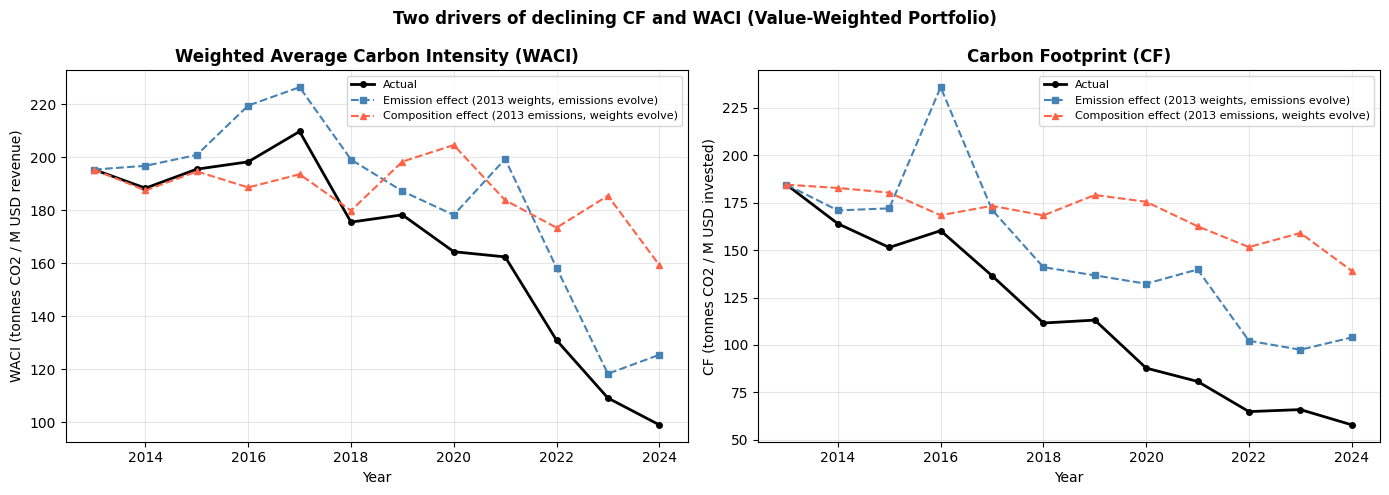

In [238]:
# Decomposition of CF and WACI into two effects:
#   Emission effect: firms reduce their own emissions/carbon intensity (freeze 2013 weights, let CI/E evolve)
#   Composition effect: portfolio tilts toward lower-carbon firms (freeze 2013 CI/E, let weights evolve)

base_info_ci_weights = inv_set_2013[['ISIN', 'MV_Y_weight', 'CI', 'CO2_S1', 'CO2_S2', 'MV_Y']].copy()
base_info_ci_weights.columns = ['ISIN', 'w_2013', 'CI_2013', 'S1_2013', 'S2_2013', 'Cap_2013']
base_info_ci_weights['E_2013'] = base_info_ci_weights['S1_2013'] + base_info_ci_weights['S2_2013']

list_ci_weights_total = []
for year in range(2013, 2025):
    inv_set_ci = globals()[f'inv_set_{year}'][['ISIN', 'MV_Y_weight', 'CI', 'CO2_S1', 'CO2_S2', 'MV_Y']].copy()
    inv_set_ci.columns = ['ISIN', 'w_Y', 'CI_Y', 'S1_Y', 'S2_Y', 'Cap_Y']
    inv_set_ci['E_Y'] = inv_set_ci['S1_Y'] + inv_set_ci['S2_Y']
    m = base_info_ci_weights.merge(inv_set_ci, on='ISIN')
    w_base = m['w_2013'] / m['w_2013'].sum()
    w_curr = m['w_Y']    / m['w_Y'].sum()
    list_ci_weights_total.append({
        'Year'                : year,
        'WACI actual'         : (w_curr * m['CI_Y']).sum(),
        'WACI frozen weights' : (w_base * m['CI_Y']).sum(),
        'WACI frozen CI'      : (w_curr * m['CI_2013']).sum(),
        'CF actual'           : (w_curr * m['E_Y']    / m['Cap_Y']).sum(),
        'CF frozen weights'   : (w_base * m['E_Y']    / m['Cap_Y']).sum(),
        'CF frozen emissions' : (w_curr * m['E_2013'] / m['Cap_2013']).sum(),
    })

decomp = pd.DataFrame(list_ci_weights_total).set_index('Year')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, actual, frozen_w, frozen_e, ylabel, title in [
    (ax1, 'WACI actual', 'WACI frozen weights', 'WACI frozen CI',
     'WACI (tonnes CO2 / M USD revenue)', 'Weighted Average Carbon Intensity (WACI)'),
    (ax2, 'CF actual', 'CF frozen weights', 'CF frozen emissions',
     'CF (tonnes CO2 / M USD invested)', 'Carbon Footprint (CF)'),
]:
    ax.plot(decomp.index, decomp[actual],   color='black',     lw=2,   marker='o', ms=4, label='Actual')
    ax.plot(decomp.index, decomp[frozen_w], color='steelblue', lw=1.5, marker='s', ms=4, ls='--', label='Emission effect (2013 weights, emissions evolve)')
    ax.plot(decomp.index, decomp[frozen_e], color='tomato',    lw=1.5, marker='^', ms=4, ls='--', label='Composition effect (2013 emissions, weights evolve)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Two drivers of declining CF and WACI (Value-Weighted Portfolio)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Long-Only Portfolio with a Carbon Footprint Objective

In [245]:
# Compute CF of unconstrained P(mv) for each year — used as the 50% constraint target
# CF(p)_Y = sum_i [ alpha_i * E_i / Cap_i ]  (tonnes CO2 per million USD invested)

cf_mv_slsqp = {}   # CF of unconstrained MV (SLSQP) per year
cf_mv_lw    = {}   # CF of unconstrained MV (LW)    per year

for year in range(2013, 2025):
    inv       = globals()[f'inv_set_{year}']
    e_per_cap = ((inv['CO2_S1'] + inv['CO2_S2']) / inv['MV_Y']).fillna(0).values

    # SLSQP: weight vector aligns with inv_set row order (same as is_{year})
    cf_mv_slsqp[year] = float(np.dot(globals()[f'min_var_weights_{year}_slsqp'], e_per_cap))

    # LW: weight vector aligns with returns_{year}_lw column order
    lw_isins       = list(globals()[f'returns_{year}_lw'].columns)
    inv_lw         = inv.set_index('ISIN').reindex(lw_isins)
    e_per_cap_lw   = ((inv_lw['CO2_S1'] + inv_lw['CO2_S2']) / inv_lw['MV_Y']).fillna(0).values
    cf_mv_lw[year] = float(np.dot(globals()[f'min_var_weights_{year}_lw'], e_per_cap_lw))

print(f"{'Year':>6}  {'CF MV SLSQP':>12}  {'CF MV LW':>10}  {'Target SLSQP':>13}  {'Target LW':>10}")
for year in range(2013, 2025):
    print(f"{year:>6}  {cf_mv_slsqp[year]:>12.1f}  {cf_mv_lw[year]:>10.1f}  "
          f"{0.5*cf_mv_slsqp[year]:>13.1f}  {0.5*cf_mv_lw[year]:>10.1f}")


  Year   CF MV SLSQP    CF MV LW   Target SLSQP   Target LW
  2013         395.5       390.4          197.7       195.2
  2014         344.5       311.0          172.3       155.5
  2015         660.6       199.5          330.3        99.8
  2016        1081.0       163.6          540.5        81.8
  2017         544.6       168.6          272.3        84.3
  2018         423.9       261.7          211.9       130.9
  2019         210.1       173.2          105.0        86.6
  2020         161.7       170.4           80.9        85.2
  2021         135.7       133.2           67.9        66.6
  2022          81.5        90.0           40.8        45.0
  2023          57.9        72.1           29.0        36.0
  2024          69.4        93.0           34.7        46.5


In [246]:
# Constrained minimum variance portfolio — SLSQP
# Added constraint: CF(p)_Y <= 0.5 * CF(P(mv))_Y  (linear in weights)

for year in range(2013, 2025):
    print(f"SLSQP constrained — {year-9}-{year}")

    inv       = globals()[f'inv_set_{year}']
    e_per_cap = ((inv['CO2_S1'] + inv['CO2_S2']) / inv['MV_Y']).fillna(0).values
    cf_target = 0.5 * cf_mv_slsqp[year]
    cov       = globals()[f'covariance_matrix_{year}'].values
    n         = globals()[f'n_assets_{year}']
    w0        = np.ones(n) / n

    def portfolio_variance(w, cov=cov):
        return w.T @ cov @ w

    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w, e=e_per_cap, t=cf_target: t - w @ e},
    ]
    bounds = tuple((0, 1) for _ in range(n))

    result = minimize(portfolio_variance, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    globals()[f'min_var_weights_{year}_cf_slsqp'] = result.x

    print(f"  Status : {result.message}")
    print(f"  CF     : {result.x @ e_per_cap:.2f}  (target <= {cf_target:.2f}, unconstrained: {cf_mv_slsqp[year]:.2f})")
    print(f"  Weights sum: {result.x.sum():.6f}")
    print()


SLSQP constrained — 2004-2013
  Status : Optimization terminated successfully
  CF     : 197.73  (target <= 197.73, unconstrained: 395.45)
  Weights sum: 1.000000

SLSQP constrained — 2005-2014
  Status : Optimization terminated successfully
  CF     : 172.27  (target <= 172.27, unconstrained: 344.53)
  Weights sum: 1.000000

SLSQP constrained — 2006-2015
  Status : Optimization terminated successfully
  CF     : 330.32  (target <= 330.32, unconstrained: 660.64)
  Weights sum: 1.000000

SLSQP constrained — 2007-2016
  Status : Optimization terminated successfully
  CF     : 540.49  (target <= 540.49, unconstrained: 1080.98)
  Weights sum: 1.000000

SLSQP constrained — 2008-2017
  Status : Optimization terminated successfully
  CF     : 272.28  (target <= 272.28, unconstrained: 544.56)
  Weights sum: 1.000000

SLSQP constrained — 2009-2018
  Status : Optimization terminated successfully
  CF     : 211.93  (target <= 211.93, unconstrained: 423.87)
  Weights sum: 1.000000

SLSQP constrain

In [247]:
# Constrained minimum variance portfolio — CVXPY with Ledoit-Wolf
# Added constraint: e_per_cap @ w <= 0.5 * CF(P(mv))_Y  (linear CVXPY constraint)

for year in range(2013, 2025):
    print(f"LW constrained — {year-9}-{year}")

    lw_isins     = list(globals()[f'returns_{year}_lw'].columns)
    inv          = globals()[f'inv_set_{year}']
    inv_lw       = inv.set_index('ISIN').reindex(lw_isins)
    e_per_cap_lw = ((inv_lw['CO2_S1'] + inv_lw['CO2_S2']) / inv_lw['MV_Y']).fillna(0).values
    cf_target    = 0.5 * cf_mv_lw[year]
    cov          = globals()[f'covariance_matrix_{year}_lw']
    n            = globals()[f'n_assets_{year}_lw']

    w           = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, cov))
    constraints = [cp.sum(w) == 1, w >= 0, e_per_cap_lw @ w <= cf_target]
    problem     = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    globals()[f'min_var_weights_{year}_cf_lw'] = w.value

    print(f"  Status : {problem.status}")
    print(f"  CF     : {float(e_per_cap_lw @ w.value):.2f}  (target <= {cf_target:.2f}, unconstrained: {cf_mv_lw[year]:.2f})")
    print(f"  Weights sum: {w.value.sum():.6f}")
    print()


LW constrained — 2004-2013
  Status : optimal
  CF     : 195.18  (target <= 195.18, unconstrained: 390.36)
  Weights sum: 1.000000

LW constrained — 2005-2014
  Status : optimal
  CF     : 155.52  (target <= 155.52, unconstrained: 311.04)
  Weights sum: 1.000000

LW constrained — 2006-2015
  Status : optimal
  CF     : 99.77  (target <= 99.77, unconstrained: 199.53)
  Weights sum: 1.000000

LW constrained — 2007-2016
  Status : optimal
  CF     : 81.82  (target <= 81.82, unconstrained: 163.63)
  Weights sum: 1.000000

LW constrained — 2008-2017
  Status : optimal
  CF     : 84.28  (target <= 84.28, unconstrained: 168.56)
  Weights sum: 1.000000

LW constrained — 2009-2018
  Status : optimal
  CF     : 130.86  (target <= 130.86, unconstrained: 261.71)
  Weights sum: 1.000000

LW constrained — 2010-2019
  Status : optimal
  CF     : 86.58  (target <= 86.58, unconstrained: 173.17)
  Weights sum: 1.000000

LW constrained — 2011-2020
  Status : optimal
  CF     : 85.21  (target <= 85.21, un

In [248]:
# Clip residual negative weights (numerical noise) to zero and renormalise
for year in range(2013, 2025):
    for suffix in ['cf_slsqp', 'cf_lw']:
        key = f'min_var_weights_{year}_{suffix}'
        w   = np.maximum(globals()[key], 0)
        globals()[key] = w / w.sum()
    print(f"{year} — SLSQP sum: {globals()[f'min_var_weights_{year}_cf_slsqp'].sum():.6f}  "
          f"LW sum: {globals()[f'min_var_weights_{year}_cf_lw'].sum():.6f}")


2013 — SLSQP sum: 1.000000  LW sum: 1.000000
2014 — SLSQP sum: 1.000000  LW sum: 1.000000
2015 — SLSQP sum: 1.000000  LW sum: 1.000000
2016 — SLSQP sum: 1.000000  LW sum: 1.000000
2017 — SLSQP sum: 1.000000  LW sum: 1.000000
2018 — SLSQP sum: 1.000000  LW sum: 1.000000
2019 — SLSQP sum: 1.000000  LW sum: 1.000000
2020 — SLSQP sum: 1.000000  LW sum: 1.000000
2021 — SLSQP sum: 1.000000  LW sum: 1.000000
2022 — SLSQP sum: 1.000000  LW sum: 1.000000
2023 — SLSQP sum: 1.000000  LW sum: 1.000000
2024 — SLSQP sum: 1.000000  LW sum: 1.000000


In [249]:
# Compute out-of-sample monthly returns — same pattern as Part I
# Weights at end of Y are applied to monthly returns of Y+1

# LW constrained (mirrors cell 46)
for year in range(2013, 2025):
    portfolio_lw = globals()[f'returns_{year}_lw'].T.copy()
    portfolio_lw['weight'] = globals()[f'min_var_weights_{year}_cf_lw']
    portfolio_lw = portfolio_lw[['weight']]
    globals()[f'carbon_mv_portfolio_{year+1}_lw_returns'] = (
        portfolio_lw
        .merge(globals()[f'is_{year+1}_returns'], left_index=True, right_on='ISIN', how='left')
        .set_index('ISIN')
    )

for year in range(2014, 2026):
    globals()[f'carbon_mv_portfolio_{year}_lw_returns'] = (
        globals()[f'carbon_mv_portfolio_{year}_lw_returns'].iloc[:, 1:]
        .mul(globals()[f'carbon_mv_portfolio_{year}_lw_returns']['weight'], axis=0)
        .sum()
    )

# SLSQP constrained (mirrors cell 48)
for year in range(2013, 2025):
    portfolio_slsqp = globals()[f'is_{year}'][['ISIN']].copy()
    portfolio_slsqp['weight'] = globals()[f'min_var_weights_{year}_cf_slsqp']
    portfolio_slsqp = portfolio_slsqp.set_index('ISIN')
    merged = portfolio_slsqp.merge(globals()[f'is_{year+1}_returns'], on='ISIN', how='left').set_index('ISIN')
    globals()[f'carbon_mv_portfolio_{year+1}_slsqp_returns'] = (
        merged.iloc[:, 1:].mul(merged['weight'], axis=0).sum()
    )


In [250]:
# Collect monthly returns into DataFrames (same structure as Part I)
carbon_mv_returns_lw_df = create_returns_dataframe(
    {year: globals()[f'carbon_mv_portfolio_{year}_lw_returns'] for year in range(2014, 2026)}
)
carbon_mv_returns_slsqp_df = create_returns_dataframe(
    {year: globals()[f'carbon_mv_portfolio_{year}_slsqp_returns'] for year in range(2014, 2026)}
)
carbon_mv_returns_lw_df


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.006551,0.046328,0.002151,0.019769,0.010268,0.009819,-0.039512,0.03098,-0.037388,0.044459,0.030083,0.003312
2015,0.003838,0.015608,-0.015848,0.004469,0.011899,-0.020249,0.051334,-0.033543,-0.005821,0.034158,-0.00344,0.022381
2016,0.002156,0.000656,0.041985,0.007375,0.016316,0.041743,0.021625,-0.041005,-0.015276,-0.036518,-0.013409,0.030567
2017,0.013686,0.020278,0.005966,0.034514,0.022808,-0.010286,0.017307,-0.046426,0.009975,0.005244,0.027633,0.025498
2018,-0.017993,-0.068925,-0.012074,0.011343,0.023075,0.017506,0.008588,0.027426,-0.00877,-0.0168,-0.011563,-0.062584
2019,0.012484,0.045619,0.036787,0.030487,-0.023589,0.045522,0.005349,-0.002189,0.007206,-0.012032,0.02889,0.058649
2020,0.007686,-0.083993,-0.119396,0.114957,0.025587,-0.00337,0.073911,0.046179,-0.017443,-0.014579,0.089713,0.030366
2021,-0.003966,-0.004251,0.078074,0.023421,0.024531,-0.013449,0.025188,0.008509,-0.05369,0.034157,-0.030163,0.081307
2022,-0.019656,-0.014169,0.044005,-0.034241,0.004165,-0.042969,0.035307,-0.027492,-0.076692,0.06777,0.065018,-0.026635
2023,0.023952,-0.007625,0.011135,0.029158,-0.04411,0.014579,0.006841,-0.02571,-0.043837,-0.015748,0.035702,0.026145


                     MV SLSQP  MV LW  MV(0.5) SLSQP  MV(0.5) LW
Ann. Return (%)         8.550   8.05          8.250       8.000
Ann. Volatility (%)    12.380  11.83         12.150      11.760
Sharpe Ratio            0.691   0.68          0.678       0.681
Min Monthly (%)       -14.690 -12.52        -13.660     -11.940
Max Monthly (%)        13.170  11.43         12.930      11.500



ValueError: setting an array element with a sequence.

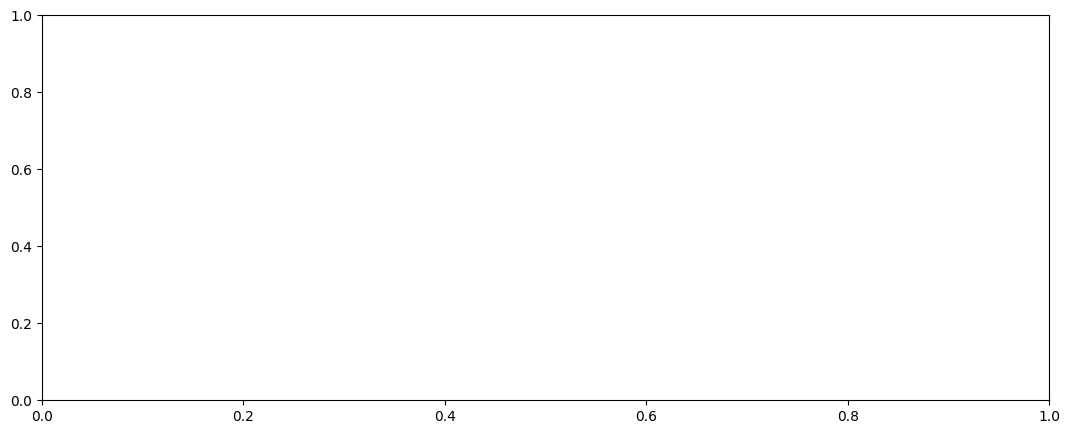

In [251]:
# Summary statistics and cumulative return comparison
# P(mv) vs P(mv)(0.5) for both methods

portfolios = {
    'MV SLSQP':            min_var_portfolio_returns_slsqp_df,
    'MV LW':               min_var_portfolio_returns_lw_df,
    'MV(0.5) SLSQP':       carbon_mv_returns_slsqp_df,
    'MV(0.5) LW':          carbon_mv_returns_lw_df,
}

stats = {}
for name, df in portfolios.items():
    r = df.stack()
    stats[name] = {
        'Ann. Return (%)':     round(((1 + r.mean())**12 - 1) * 100, 2),
        'Ann. Volatility (%)': round(r.std() * np.sqrt(12) * 100, 2),
        'Sharpe Ratio':        round(((1 + r.mean())**12 - 1) / (r.std() * np.sqrt(12)), 3),
        'Min Monthly (%)':     round(r.min() * 100, 2),
        'Max Monthly (%)':     round(r.max() * 100, 2),
    }
stats_df = pd.DataFrame(stats)
print(stats_df.to_string())
print()

# Cumulative return plot
fig, ax = plt.subplots(figsize=(13, 5))
styles = {'MV SLSQP': ('steelblue','--'), 'MV LW': ('steelblue','-'),
          'MV(0.5) SLSQP': ('tomato','--'), 'MV(0.5) LW': ('tomato','-')}
for name, df in portfolios.items():
    cum = (1 + df.stack()).cumprod()
    color, ls = styles[name]
    ax.plot(cum.index, cum.values, label=name, color=color, linestyle=ls, linewidth=1.8)
ax.set_title('Cumulative Returns: P(mv) vs P(mv)(0.5)', fontweight='bold')
ax.set_ylabel('Cumulative Return (base 1)')
ax.set_xlabel('Date')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
